# 🔬 ECE-226: Roofline Benchmarking & LLM Kernel Profiling
## Benchmarking Methodologies & Profiling Ecosystems — Unified Notebook

---

### 📌 Overview

This notebook is the **single source of truth** for the benchmarking project.

| Stage | Tool / Method | What it answers |
|-------|--------------|----------------|
| **Hardware characterization** | Measured peaks (CUDA timers) + spec lookup | What are the physical limits of this GPU? |
| **Roofline construction** | Theoretical & empirical model | Where is the memory-vs-compute ridge? |
| **Kernel measurement** | Custom harness (warmup + sync) | How fast do GEMM / Add / Softmax run? |
| **Kernel mapping** | OI + achieved GFLOPs | Where do kernels sit on the roofline? |
| **System-level profiling** | **Nsight Systems (nsys)** | How does the GPU timeline look? CPU overhead? |
| **Optimization conclusion** | Roofline classification | Memory-bound → fuse/quantize; Compute-bound → Tensor Cores |

**The three LLM kernels studied:**

| Kernel | Role in Transformer | Expected bound |
|--------|---------------------|----------------|
| **GEMM** | Q/K/V projections, MLP layers | Compute-bound at large sizes |
| **Element-wise Add** | Residual connections | Always memory-bound |
| **Softmax** | Attention score normalization | Memory-bound |

**➡️  Run cells top-to-bottom on a Colab L4 GPU runtime.**


---
## Section 0 — Environment Setup

Install required packages and verify the GPU. We set deterministic seeds and disable cuDNN
auto-tuning so timing measurements are reproducible across runs.


In [1]:
!pip install tabulate --quiet

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import warnings, time, os, subprocess, sqlite3, textwrap
from tabulate import tabulate

warnings.filterwarnings('ignore')

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.benchmark    = False
torch.backends.cudnn.deterministic = True

assert torch.cuda.is_available(), "No GPU! Go to Runtime > Change runtime type > GPU"
device = torch.device("cuda")
print(f"✅ GPU detected : {torch.cuda.get_device_name(0)}")
print(f"✅ PyTorch      : {torch.__version__}")
print(f"✅ CUDA runtime : {torch.version.cuda}")


✅ GPU detected : NVIDIA L4
✅ PyTorch      : 2.10.0+cu128
✅ CUDA runtime : 12.8


---
## Section 1 — Hardware Characterization

### 1a — GPU Specification Lookup

Every GPU has two fundamental bottlenecks:
- **Peak Compute** — maximum math throughput (TFLOP/s)
- **Peak Memory Bandwidth** — maximum HBM read/write speed (GB/s)

These define the two "roofs" in the Roofline Model. We look them up from NVIDIA official datasheets.


In [2]:
GPU_SPECS = {
    "NVIDIA L4":               {"fp32": 30.3,  "fp16": 242.0, "bw": 300.0,  "vram_gb": 24},
    "Tesla T4":                {"fp32": 8.1,   "fp16": 65.0,  "bw": 300.0,  "vram_gb": 16},
    "Tesla V100-SXM2-16GB":    {"fp32": 15.7,  "fp16": 125.0, "bw": 900.0,  "vram_gb": 16},
    "Tesla V100-PCIE-16GB":    {"fp32": 14.1,  "fp16": 112.0, "bw": 897.0,  "vram_gb": 16},
    "NVIDIA A100-SXM4-40GB":   {"fp32": 19.5,  "fp16": 312.0, "bw": 1555.0, "vram_gb": 40},
    "NVIDIA A100-SXM4-80GB":   {"fp32": 19.5,  "fp16": 312.0, "bw": 2000.0, "vram_gb": 80},
    "NVIDIA A100-PCIE":        {"fp32": 19.5,  "fp16": 312.0, "bw": 1935.0, "vram_gb": 40},
    "NVIDIA GeForce RTX 4090":  {"fp32": 82.6,  "fp16": 165.2, "bw": 1008.0, "vram_gb": 24},
    "NVIDIA GeForce RTX 3090":  {"fp32": 35.6,  "fp16": 35.6,  "bw": 936.0,  "vram_gb": 24},
    "NVIDIA GeForce GTX 1080 Ti": {"fp32": 11.3, "fp16": 0.18, "bw": 484.0,  "vram_gb": 11},
}

gpu_name = torch.cuda.get_device_name(0)
print(f"Detected GPU: '{gpu_name}'")

specs = GPU_SPECS.get(gpu_name)
if specs is None:
    for key in GPU_SPECS:
        if key.lower() in gpu_name.lower() or gpu_name.lower() in key.lower():
            specs = GPU_SPECS[key]
            print(f"  Matched to known entry: '{key}'")
            break

if specs is None:
    print("  GPU not in database — using safe fallback estimates.")
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    specs = {"fp32": 10.0, "fp16": 20.0, "bw": 300.0, "vram_gb": round(vram, 1)}

PEAK_FP32_TFLOPS = specs["fp32"]
PEAK_FP16_TFLOPS = specs["fp16"]
PEAK_BW_GBs      = specs["bw"]

props         = torch.cuda.get_device_properties(0)
NUM_SMS       = props.multi_processor_count
SHARED_MEM_KB = props.shared_memory_per_block // 1024
TOTAL_MEM_GB  = props.total_memory / 1e9

print("\n" + "="*55)
print("       GPU HARDWARE SPECIFICATION TABLE")
print("="*55)
hw_data = [
    ["GPU Model",                       gpu_name],
    ["VRAM (runtime)",                  f"{TOTAL_MEM_GB:.1f} GB"],
    ["Streaming Multiprocessors",       str(NUM_SMS)],
    ["Shared Memory per Block",         f"{SHARED_MEM_KB} KB"],
    ["Peak FP32 Compute (spec)",        f"{PEAK_FP32_TFLOPS:.1f} TFLOP/s"],
    ["Peak FP16 Compute (Tensor Core)", f"{PEAK_FP16_TFLOPS:.1f} TFLOP/s"],
    ["FP16 / FP32 Speedup",            f"{PEAK_FP16_TFLOPS/PEAK_FP32_TFLOPS:.1f}x"],
    ["Peak Memory Bandwidth (spec)",    f"{PEAK_BW_GBs:.1f} GB/s"],
    ["PyTorch version",                 torch.__version__],
    ["CUDA version",                    torch.version.cuda],
]
print(tabulate(hw_data, headers=["Parameter", "Value"], tablefmt="grid"))


Detected GPU: 'NVIDIA L4'

       GPU HARDWARE SPECIFICATION TABLE
+---------------------------------+---------------+
| Parameter                       | Value         |
+=================================+===============+
| GPU Model                       | NVIDIA L4     |
+---------------------------------+---------------+
| VRAM (runtime)                  | 23.7 GB       |
+---------------------------------+---------------+
| Streaming Multiprocessors       | 58            |
+---------------------------------+---------------+
| Shared Memory per Block         | 48 KB         |
+---------------------------------+---------------+
| Peak FP32 Compute (spec)        | 30.3 TFLOP/s  |
+---------------------------------+---------------+
| Peak FP16 Compute (Tensor Core) | 242.0 TFLOP/s |
+---------------------------------+---------------+
| FP16 / FP32 Speedup             | 8.0x          |
+---------------------------------+---------------+
| Peak Memory Bandwidth (spec)    | 300.0 GB/s   

---
### 1b — Empirically Measured Peak Bandwidth & Compute

Spec-sheet numbers are theoretical maxima. Real-world results are lower due to clock throttling,
memory controller overhead, and power limits. We **measure** peaks empirically:
- **Bandwidth**: vector TRIAD (`C = A + B`) to saturate HBM  
- **Compute**: large square GEMM to saturate tensor cores

The notebook plots both the theoretical and empirically-attainable roofline.

> ⏳ This cell takes ~60 seconds.


In [3]:
class CUDATimer:
    """Precise GPU timer using CUDA events (avoids CPU/GPU async ambiguity)."""
    def __init__(self):
        self.se = torch.cuda.Event(enable_timing=True)
        self.ee = torch.cuda.Event(enable_timing=True)

    def time_ms(self, fn, iters=100, warmup=20):
        for _ in range(warmup): fn()
        torch.cuda.synchronize()
        self.se.record()
        for _ in range(iters): fn()
        self.ee.record()
        torch.cuda.synchronize()
        return self.se.elapsed_time(self.ee) / iters


def measure_peak_bandwidth(dtype=torch.float32, target_gib=1.0, iters=200, warmup=50):
    """Vector TRIAD C=A+B — traffic = 3 x N x elem_size bytes."""
    timer = CUDATimer()
    free_bytes, _ = torch.cuda.mem_get_info()
    bytes_per_tensor = int(min(target_gib*(1024**3), free_bytes*0.80//3))
    elem_size = torch.tensor([], dtype=dtype).element_size()
    N = (bytes_per_tensor // elem_size // 256) * 256
    A = torch.randn(N, device=device, dtype=dtype)
    B = torch.randn(N, device=device, dtype=dtype)
    C = torch.empty(N, device=device, dtype=dtype)
    ms = timer.time_ms(lambda: torch.add(A, B, out=C), iters=iters, warmup=warmup)
    GBps = (3*N*elem_size / (ms/1e3)) / 1e9
    del A, B, C; torch.cuda.empty_cache()
    return GBps


def measure_peak_tflops(dtype=torch.float16, sizes=(4096,6144,8192), iters=50, warmup=10):
    """Square GEMM — FLOPs = 2 x n^3."""
    timer = CUDATimer()
    torch.backends.cuda.matmul.allow_tf32 = (dtype == torch.float32)
    best = 0.0
    for n in sizes:
        elem_size = torch.tensor([], dtype=dtype).element_size()
        if 3*n*n*elem_size > torch.cuda.mem_get_info()[0]*0.7:
            print(f"  Skipping n={n} (OOM risk)")
            continue
        A = torch.randn((n,n), device=device, dtype=dtype)
        B = torch.randn((n,n), device=device, dtype=dtype)
        ms = timer.time_ms(lambda: torch.matmul(A, B), iters=iters, warmup=warmup)
        best = max(best, (2.0*n**3)/(ms/1e3)/1e12)
        del A, B; torch.cuda.empty_cache()
    return best


print("Measuring empirical peaks (takes ~60 s) ...")
meas_bw   = max(measure_peak_bandwidth(torch.float32),
                measure_peak_bandwidth(torch.float16))
meas_fp16 = measure_peak_tflops(torch.float16, sizes=(4096,6144,8192))
meas_fp32 = measure_peak_tflops(torch.float32, sizes=(2048,3072,4096))

print("\n📐 Measured vs Theoretical:")
rows = [
    ["Peak Bandwidth",    f"{meas_bw:.1f} GB/s",    f"{PEAK_BW_GBs:.1f} GB/s",    f"{100*meas_bw/PEAK_BW_GBs:.0f}%"],
    ["Peak FP16 Compute", f"{meas_fp16:.2f} TFLOP/s",f"{PEAK_FP16_TFLOPS:.1f} TFLOP/s",f"{100*meas_fp16/PEAK_FP16_TFLOPS:.0f}%"],
    ["Peak FP32 Compute", f"{meas_fp32:.2f} TFLOP/s",f"{PEAK_FP32_TFLOPS:.1f} TFLOP/s",f"{100*meas_fp32/PEAK_FP32_TFLOPS:.0f}%"],
]
print(tabulate(rows, headers=["Metric","Measured","Spec-Sheet","Attainment"], tablefmt="grid"))
print("\nThe 'attainment' row shows real-world efficiency.")
print("We plot BOTH the spec-sheet roof AND the measured attainable roof.")


Measuring empirical peaks (takes ~60 s) ...

📐 Measured vs Theoretical:
+-------------------+---------------+---------------+--------------+
| Metric            | Measured      | Spec-Sheet    | Attainment   |
+===================+===============+===============+==============+
| Peak Bandwidth    | 232.9 GB/s    | 300.0 GB/s    | 78%          |
+-------------------+---------------+---------------+--------------+
| Peak FP16 Compute | 61.32 TFLOP/s | 242.0 TFLOP/s | 25%          |
+-------------------+---------------+---------------+--------------+
| Peak FP32 Compute | 37.63 TFLOP/s | 30.3 TFLOP/s  | 124%         |
+-------------------+---------------+---------------+--------------+

The 'attainment' row shows real-world efficiency.
We plot BOTH the spec-sheet roof AND the measured attainable roof.


---
## Section 2 — Construct the Theoretical & Empirical Roofline

### What is the Roofline Model?

| Axis | Meaning |
|------|---------|
| **X — Operational Intensity (OI)** | FLOPs ÷ Bytes ("how much math per byte loaded?") |
| **Y — Performance** | FLOPs ÷ Time ("how fast does it run?") |

The "roof" has two segments:
1. **Memory-bandwidth segment** — slope = BW: `Perf = OI × BW`
2. **Compute ceiling** — flat at peak compute

The **ridge point** is their intersection: `OI_ridge = Peak_Compute / Peak_BW`.  
Kernels **left** of the ridge are **memory-bound**; **right** are **compute-bound**.

We plot four rooflines: FP32 and FP16, each in spec-sheet and empirically-measured form.


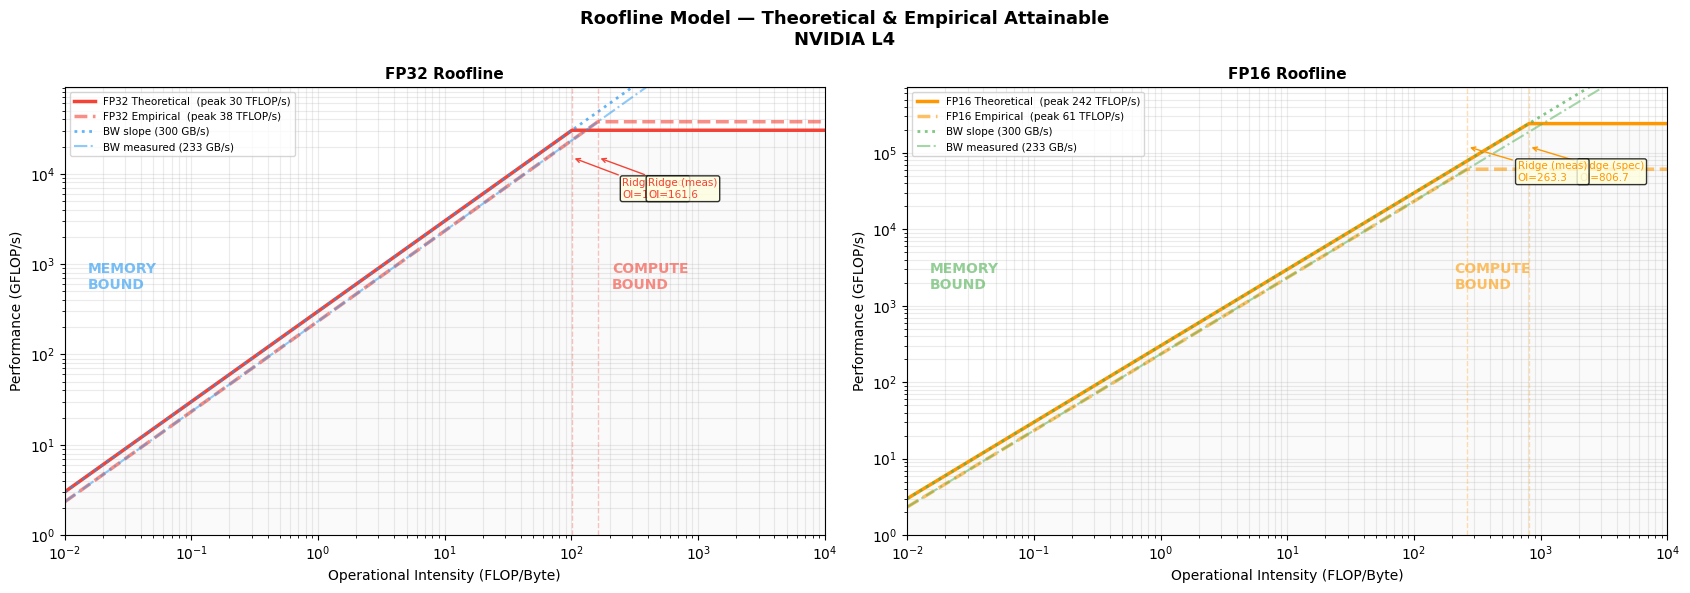

Ridge points (OI boundary between memory-bound and compute-bound):
  FP32 (spec): 101.00 FLOP/Byte
  FP16 (spec): 806.67 FLOP/Byte
  FP16 compute ceiling is 8x higher than FP32,
  but the memory bandwidth roof stays the SAME.
  FP16 only helps compute-bound kernels.


In [4]:
def draw_roofline(ax, compute_tflops, bw_gbps, label, color, linestyle='-', alpha=1.0):
    comp_gflops = compute_tflops * 1000
    oi_range    = np.logspace(-2, 4, 600)
    ax.plot(oi_range, np.minimum(comp_gflops, oi_range * bw_gbps),
            color=color, linestyle=linestyle, linewidth=2.5, alpha=alpha,
            label=f"{label}  (peak {compute_tflops:.0f} TFLOP/s)")
    return comp_gflops / bw_gbps


fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle(f'Roofline Model — Theoretical & Empirical Attainable\n{gpu_name}',
             fontsize=13, fontweight='bold')

for ax, prec, t_comp, m_comp, bw_c, comp_c in [
    (axes[0], "FP32", PEAK_FP32_TFLOPS, meas_fp32, '#2196F3', '#F44336'),
    (axes[1], "FP16", PEAK_FP16_TFLOPS, meas_fp16, '#4CAF50', '#FF9800'),
]:
    ax.set_xscale('log'); ax.set_yscale('log')

    ridge_th = draw_roofline(ax, t_comp, PEAK_BW_GBs, f"{prec} Theoretical", comp_c, '-')
    ridge_em = draw_roofline(ax, m_comp, meas_bw,     f"{prec} Empirical",   comp_c, '--', alpha=0.6)

    oi_r = np.logspace(-2, 4, 400)
    ax.plot(oi_r, oi_r * PEAK_BW_GBs, color=bw_c, linestyle=':', linewidth=2, alpha=0.7,
            label=f'BW slope ({PEAK_BW_GBs:.0f} GB/s)')
    ax.plot(oi_r, oi_r * meas_bw, color=bw_c, linestyle='-.', linewidth=1.5, alpha=0.5,
            label=f'BW measured ({meas_bw:.0f} GB/s)')

    for ridge, rtxt in [(ridge_th, 'Ridge (spec)'), (ridge_em, 'Ridge (meas)')]:
        ax.axvline(x=ridge, color=comp_c, linestyle='--', alpha=0.3, linewidth=1)
        ax.annotate(f"{rtxt}\nOI={ridge:.1f}",
                    xy=(ridge, t_comp*500), xytext=(ridge*2.5, t_comp*180),
                    fontsize=7.5, color=comp_c,
                    arrowprops=dict(arrowstyle='->', color=comp_c, lw=1),
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.8))

    ax.fill_between(oi_r, np.minimum(t_comp*1000, oi_r*PEAK_BW_GBs),
                    alpha=0.04, color='gray')
    ax.set_xlim([1e-2, 1e4]); ax.set_ylim([1, t_comp*3000])
    ax.set_xlabel('Operational Intensity (FLOP/Byte)', fontsize=10)
    ax.set_ylabel('Performance (GFLOP/s)', fontsize=10)
    ax.set_title(f'{prec} Roofline', fontsize=11, fontweight='bold')
    ax.legend(fontsize=7.5, loc='upper left')
    ax.grid(True, which='both', alpha=0.25)
    ax.text(0.03, 0.55, 'MEMORY\nBOUND', transform=ax.transAxes,
            fontsize=10, color=bw_c, fontweight='bold', alpha=0.6)
    ax.text(0.72, 0.55, 'COMPUTE\nBOUND', transform=ax.transAxes,
            fontsize=10, color=comp_c, fontweight='bold', alpha=0.6)

plt.tight_layout()
plt.savefig('roofline_theoretical.png', dpi=150, bbox_inches='tight')
plt.show()

ridge_fp32 = (PEAK_FP32_TFLOPS * 1000) / PEAK_BW_GBs
ridge_fp16 = (PEAK_FP16_TFLOPS * 1000) / PEAK_BW_GBs
print(f"Ridge points (OI boundary between memory-bound and compute-bound):")
print(f"  FP32 (spec): {ridge_fp32:.2f} FLOP/Byte")
print(f"  FP16 (spec): {ridge_fp16:.2f} FLOP/Byte")
print(f"  FP16 compute ceiling is {PEAK_FP16_TFLOPS/PEAK_FP32_TFLOPS:.0f}x higher than FP32,")
print(f"  but the memory bandwidth roof stays the SAME.")
print(f"  FP16 only helps compute-bound kernels.")


---
## Section 3 — Kernel Definitions & FLOPs/Memory Formulas

To place a kernel on the roofline we need:
- **FLOPs** — how many arithmetic operations does this kernel perform?
- **Memory bytes** — how many bytes does it read/write from HBM?

Their ratio is the **Operational Intensity (OI)**: `OI = FLOPs / Bytes`.

| Kernel | FLOPs formula | Memory formula | OI trend |
|--------|--------------|----------------|----------|
| GEMM | `2 × B × N × D²` | `eb × (BND + D² + BND)` | Grows with D (weight reuse) |
| Element-wise Add | `B × N × D` | `eb × 3 × BND` | Constant ≈ 0.08–0.17 F/B |
| Softmax | `B × N × 5N` | `eb × 2 × BN²` | Constant ≈ 2.5 F/B |

(eb = bytes per element; B=batch, N=seq_len, D=hidden_dim)


In [5]:
def run_gemm(B, N, D, dtype):
    """Q/K/V projections and feed-forward layers."""
    A = torch.randn(B*N, D, dtype=dtype, device=device)
    W = torch.randn(D, D, dtype=dtype, device=device)
    with torch.no_grad(): return torch.matmul(A, W)

def run_add(B, N, D, dtype):
    """Residual / skip connections."""
    A  = torch.randn(B, N, D, dtype=dtype, device=device)
    Bm = torch.randn(B, N, D, dtype=dtype, device=device)
    with torch.no_grad(): return torch.add(A, Bm)

def run_softmax(B, N, dtype):
    """Attention score normalisation."""
    A = torch.randn(B, N, N, dtype=dtype, device=device)
    with torch.no_grad(): return torch.softmax(A, dim=-1)

# FLOPs & Memory Traffic formulas
def gemm_flops(B, N, D):     return 2 * B * N * D * D
def gemm_bytes(B, N, D, eb): return eb * (B*N*D + D*D + B*N*D)
def add_flops(B, N, D):      return B * N * D
def add_bytes(B, N, D, eb):  return eb * 3 * B * N * D
def softmax_flops(B, N):     return B * N * 5 * N
def softmax_bytes(B, N, eb): return eb * 2 * B * N * N

print("Kernel functions and FLOPs/Memory formulas defined.")
rows = [
    ["GEMM",           "2 x B x N x D^2",  "eb x (BND + D^2 + BND)"],
    ["Element-wise Add","B x N x D",        "eb x 3 x BND"],
    ["Softmax",         "B x N x 5N",       "eb x 2 x BN^2"],
]
print(tabulate(rows, headers=["Kernel","FLOPs","Memory Bytes"], tablefmt="grid"))


Kernel functions and FLOPs/Memory formulas defined.
+------------------+-----------------+------------------------+
| Kernel           | FLOPs           | Memory Bytes           |
+==================+=================+========================+
| GEMM             | 2 x B x N x D^2 | eb x (BND + D^2 + BND) |
+------------------+-----------------+------------------------+
| Element-wise Add | B x N x D       | eb x 3 x BND           |
+------------------+-----------------+------------------------+
| Softmax          | B x N x 5N      | eb x 2 x BN^2          |
+------------------+-----------------+------------------------+


---
## Section 4 — Benchmarking Harness

### Why naïve timing fails on GPUs

CUDA launches are **asynchronous**: `torch.matmul()` returns immediately while the GPU is still
computing. Without `torch.cuda.synchronize()` you record near-zero "CPU dispatch" time — not
actual GPU execution.

We also use:
- **20 warm-up iterations** — discards JIT compilation and cache cold-start overhead
- **100 timed iterations** — averages out micro-jitter
- **3 independent repeats** — enables mean ± std reporting


In [6]:
def benchmark_kernel(kernel_fn, warmup=20, timed=100, repeats=3):
    """
    Accurate GPU latency measurement.

    Protocol:
      1.  Run kernel_fn `warmup` times (discarded — removes JIT / cold-start)
      2.  torch.cuda.synchronize()  ← flush pipeline
      3.  For each repeat:
            synchronize → start perf_counter → run `timed` iters
            → synchronize → stop perf_counter
      4.  Return mean, std across repeats (ms per iteration)

    The synchronize() call BOTH before AND after the timed block is critical:
      Before: ensures no prior work bleeds into our window
      After:  ensures the GPU has actually finished before we stop the clock
    """
    with torch.no_grad():
        for _ in range(warmup): kernel_fn()
    torch.cuda.synchronize()

    times = []
    for _ in range(repeats):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            for _ in range(timed): kernel_fn()
        torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000 / timed)

    return float(np.mean(times)), float(np.std(times))


print("Benchmarking harness defined.")
print()
checklist = [
    ["OK", "Warm-up iterations",         "20  — discards cold-start / JIT overhead"],
    ["OK", "Timed iterations",           "100 — averages out micro-jitter"],
    ["OK", "cuda.synchronize() before",  "Ensures GPU is idle before window opens"],
    ["OK", "cuda.synchronize() after",   "Ensures GPU has finished before clock stops"],
    ["OK", "torch.no_grad()",            "No autograd overhead inside timing loop"],
    ["OK", "3 independent repeats",      "Reports mean +/- std for variance analysis"],
    ["OK", "Determinism seeds (42)",     "cuDNN deterministic=True, benchmark=False"],
]
print(tabulate(checklist, headers=["Check","Control","Rationale"], tablefmt="grid"))


Benchmarking harness defined.

+---------+---------------------------+---------------------------------------------+
| Check   | Control                   | Rationale                                   |
+=========+===========================+=============================================+
| OK      | Warm-up iterations        | 20  — discards cold-start / JIT overhead    |
+---------+---------------------------+---------------------------------------------+
| OK      | Timed iterations          | 100 — averages out micro-jitter             |
+---------+---------------------------+---------------------------------------------+
| OK      | cuda.synchronize() before | Ensures GPU is idle before window opens     |
+---------+---------------------------+---------------------------------------------+
| OK      | cuda.synchronize() after  | Ensures GPU has finished before clock stops |
+---------+---------------------------+---------------------------------------------+
| OK      | torch.no_gr

---
## Section 5 — Size & Precision Sweep

We run all three kernels across:
- **5 sizes:** D = N ∈ {256, 512, 1024, 2048, 4096}
- **2 precisions:** FP32 (4 bytes/element) and FP16 (2 bytes/element)

> ⏳ This cell takes 3–8 minutes — normal for a thorough sweep.


In [7]:
SIZES      = [256, 512, 1024, 2048, 4096]
PRECISIONS = {"FP32": (torch.float32, 4), "FP16": (torch.float16, 2)}
BATCH_SIZE = 1

results = []
print(f"Running {len(SIZES)*len(PRECISIONS)*3} experiments ...")
print(f"{'Kernel':<22} {'Prec':<5} {'D=N':<6} {'Latency(ms)':<13} {'OI':^10} {'GFLOPs':>8}")
print("-"*68)

for prec_name, (dtype, eb) in PRECISIONS.items():
    for D in SIZES:
        N = D; B = BATCH_SIZE
        for kname, fn_b, flops_fn, bytes_fn in [
            ("GEMM",
             lambda B=B,N=N,D=D,dtype=dtype: run_gemm(B,N,D,dtype),
             lambda: gemm_flops(B,N,D),
             lambda: gemm_bytes(B,N,D,eb)),
            ("Element-wise Add",
             lambda B=B,N=N,D=D,dtype=dtype: run_add(B,N,D,dtype),
             lambda: add_flops(B,N,D),
             lambda: add_bytes(B,N,D,eb)),
            ("Softmax",
             lambda B=B,N=N,dtype=dtype: run_softmax(B,N,dtype),
             lambda: softmax_flops(B,N),
             lambda: softmax_bytes(B,N,eb)),
        ]:
            lat_mean, lat_std = benchmark_kernel(fn_b)
            flops = flops_fn(); mem = bytes_fn()
            oi    = flops / mem
            gflops = (flops/1e9) / (lat_mean/1000)
            results.append({
                "kernel":kname, "precision":prec_name,
                "batch":B, "hidden_dim":D, "seq_len":N,
                "latency_ms":lat_mean, "latency_std":lat_std,
                "flops":flops, "memory_bytes":mem,
                "operational_intensity":oi, "achieved_gflops":gflops,
            })
            print(f"{kname:<22} {prec_name:<5} {D:<6} {lat_mean:<13.4f} {oi:^10.3f} {gflops:>8.1f}")
    print()

df = pd.DataFrame(results)
df.to_csv('benchmark_results.csv', index=False)
print("Sweep complete. Results saved to benchmark_results.csv")


Running 30 experiments ...
Kernel                 Prec  D=N    Latency(ms)       OI       GFLOPs
--------------------------------------------------------------------
GEMM                   FP32  256    0.0548          42.667      612.7
Element-wise Add       FP32  256    0.0356          0.083         1.8
Softmax                FP32  256    0.0254          0.625        12.9
GEMM                   FP32  512    0.0473          85.333     5678.4
Element-wise Add       FP32  512    0.0356          0.083         7.4
Softmax                FP32  512    0.0249          0.625        52.6
GEMM                   FP32  1024   0.1096         170.667    19602.2
Element-wise Add       FP32  1024   0.0489          0.083        21.4
Softmax                FP32  1024   0.0312          0.625       167.9
GEMM                   FP32  2048   0.6924         341.333    24813.6
Element-wise Add       FP32  2048   0.1933          0.083        21.7
Softmax                FP32  2048   0.0802          0.625       

---
## Section 6 — Complete Results Table


In [8]:
print("="*108)
print("                     COMPLETE BENCHMARK RESULTS TABLE")
print("="*108)

show = df[['kernel','precision','hidden_dim','latency_ms',
           'flops','memory_bytes','operational_intensity','achieved_gflops']].copy()
show['flops']        = show['flops'].apply(lambda x: f"{x:.2e}")
show['memory_bytes'] = show['memory_bytes'].apply(lambda x: f"{x:.2e}")
show['latency_ms']   = show['latency_ms'].apply(lambda x: f"{x:.4f}")
show['operational_intensity'] = show['operational_intensity'].apply(lambda x: f"{x:.4f}")
show['achieved_gflops']       = show['achieved_gflops'].apply(lambda x: f"{x:.2f}")
show.columns = ['Kernel','Prec','D=N','Latency(ms)','FLOPs','MemBytes','OI(F/B)','GFLOPs']
print(tabulate(show, headers='keys', tablefmt='grid', showindex=False))


                     COMPLETE BENCHMARK RESULTS TABLE
+------------------+--------+-------+---------------+---------------+---------------+-----------+----------+
| Kernel           | Prec   |   D=N |   Latency(ms) |         FLOPs |      MemBytes |   OI(F/B) |   GFLOPs |
+==================+========+=======+===============+===============+===============+===========+==========+
| GEMM             | FP32   |   256 |        0.0548 |      3.36e+07 | 786000        |   42.6667 |   612.7  |
+------------------+--------+-------+---------------+---------------+---------------+-----------+----------+
| Element-wise Add | FP32   |   256 |        0.0356 |  65500        | 786000        |    0.0833 |     1.84 |
+------------------+--------+-------+---------------+---------------+---------------+-----------+----------+
| Softmax          | FP32   |   256 |        0.0254 | 328000        | 524000        |    0.625  |    12.92 |
+------------------+--------+-------+---------------+---------------+-----

---
## Section 7 — Latency vs Problem Size

How each kernel's latency scales with input size. The shaded band is ±1 std-dev.


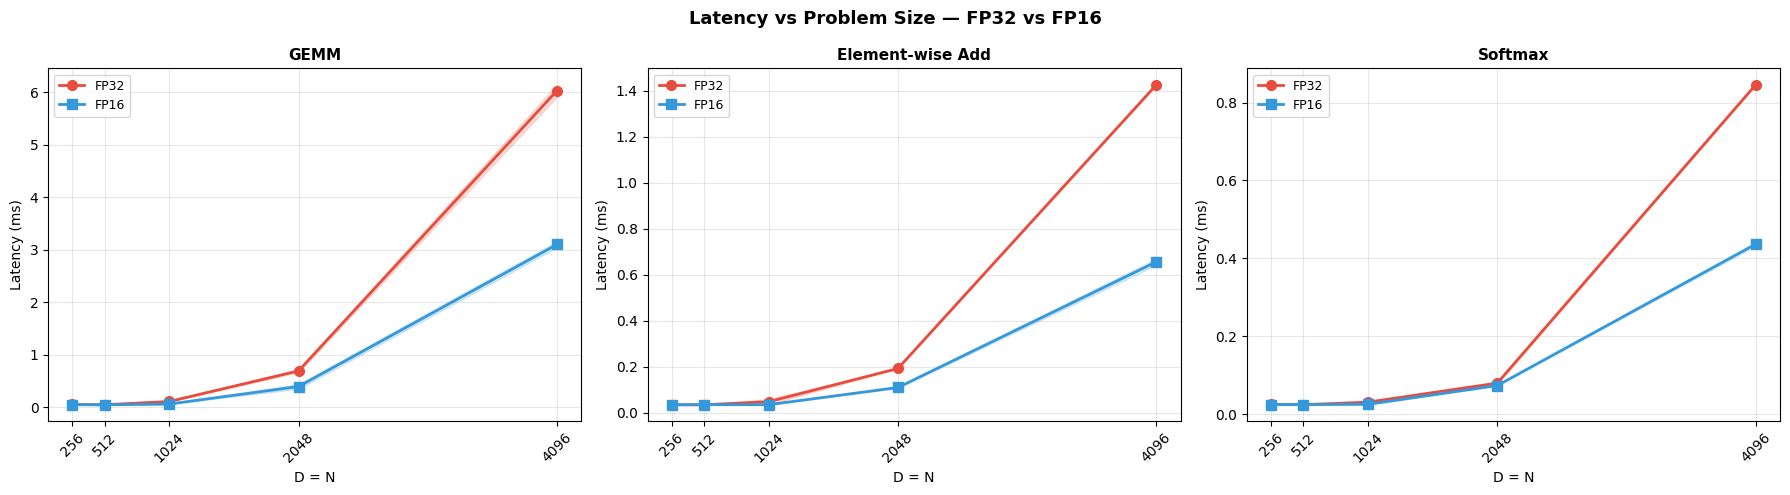


FP16 latency speedup over FP32:
+------------------+---------+---------+----------+----------+----------+
| Kernel           | D=256   | D=512   | D=1024   | D=2048   | D=4096   |
+==================+=========+=========+==========+==========+==========+
| GEMM             | 1.15x   | 1.02x   | 1.80x    | 1.75x    | 1.95x    |
+------------------+---------+---------+----------+----------+----------+
| Element-wise Add | 1.01x   | 0.99x   | 1.36x    | 1.75x    | 2.17x    |
+------------------+---------+---------+----------+----------+----------+
| Softmax          | 1.02x   | 0.99x   | 1.20x    | 1.08x    | 1.94x    |
+------------------+---------+---------+----------+----------+----------+


In [9]:
kcolors  = {'FP32': '#E74C3C', 'FP16': '#3498DB'}
kmarkers = {'FP32': 'o',       'FP16': 's'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Latency vs Problem Size — FP32 vs FP16', fontsize=13, fontweight='bold')

for ax, kname in zip(axes, ['GEMM','Element-wise Add','Softmax']):
    kdf = df[df['kernel'] == kname]
    for prec in ['FP32','FP16']:
        sub = kdf[kdf['precision']==prec].sort_values('hidden_dim')
        ax.plot(sub['hidden_dim'], sub['latency_ms'],
                color=kcolors[prec], marker=kmarkers[prec], linewidth=2, markersize=7, label=prec)
        ax.fill_between(sub['hidden_dim'],
                        sub['latency_ms'] - sub['latency_std'],
                        sub['latency_ms'] + sub['latency_std'],
                        alpha=0.18, color=kcolors[prec])
    ax.set_xlabel('D = N', fontsize=10); ax.set_ylabel('Latency (ms)', fontsize=10)
    ax.set_title(kname, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    ax.set_xticks(SIZES); ax.set_xticklabels(SIZES, rotation=45)

plt.tight_layout()
plt.savefig('latency_vs_size.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFP16 latency speedup over FP32:")
rows = []
for kname in ['GEMM','Element-wise Add','Softmax']:
    row = [kname]
    for D in SIZES:
        l32 = df[(df['kernel']==kname)&(df['precision']=='FP32')&(df['hidden_dim']==D)]['latency_ms'].values[0]
        l16 = df[(df['kernel']==kname)&(df['precision']=='FP16')&(df['hidden_dim']==D)]['latency_ms'].values[0]
        row.append(f"{l32/l16:.2f}x")
    rows.append(row)
print(tabulate(rows, headers=['Kernel']+[f'D={d}' for d in SIZES], tablefmt='grid'))


---
## Section 8 — Operational Intensity (OI) vs Problem Size

OI = FLOPs / Bytes. The dashed horizontal lines mark the **ridge points** — the boundary between
memory-bound and compute-bound. **Key insight:** GEMM OI grows with D (weight reuse), while
Add and Softmax OI are constant — they are intrinsically memory-bound at every size.


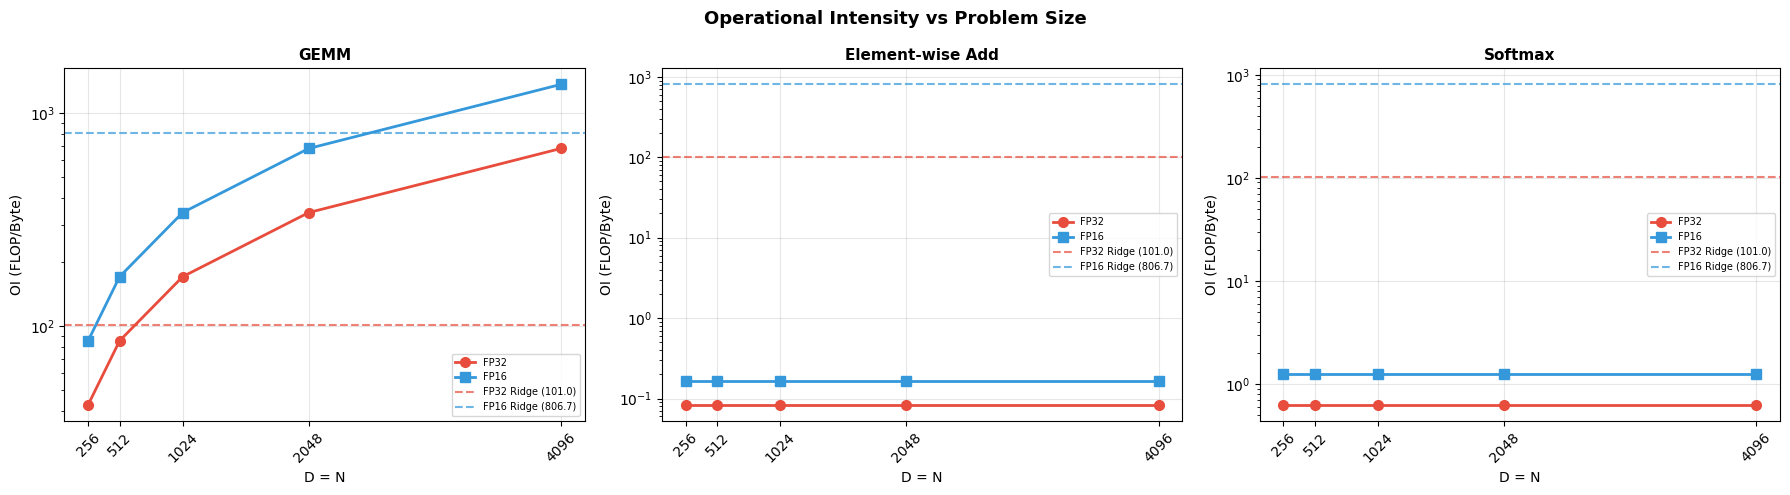

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Operational Intensity vs Problem Size', fontsize=13, fontweight='bold')

for ax, kname in zip(axes, ['GEMM','Element-wise Add','Softmax']):
    kdf = df[df['kernel'] == kname]
    for prec, color in kcolors.items():
        sub = kdf[kdf['precision']==prec].sort_values('hidden_dim')
        ax.plot(sub['hidden_dim'], sub['operational_intensity'],
                color=color, marker=kmarkers[prec], linewidth=2, markersize=7, label=prec)
    ax.axhline(y=ridge_fp32, color='#E74C3C', linestyle='--', alpha=0.7, linewidth=1.5,
               label=f'FP32 Ridge ({ridge_fp32:.1f})')
    ax.axhline(y=ridge_fp16, color='#3498DB', linestyle='--', alpha=0.7, linewidth=1.5,
               label=f'FP16 Ridge ({ridge_fp16:.1f})')
    ax.set_xlabel('D = N', fontsize=10); ax.set_ylabel('OI (FLOP/Byte)', fontsize=10)
    ax.set_title(kname, fontsize=11, fontweight='bold')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3); ax.set_yscale('log')
    ax.set_xticks(SIZES); ax.set_xticklabels(SIZES, rotation=45)

plt.tight_layout()
plt.savefig('oi_vs_size.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 9 — Achieved Performance (GFLOPs) vs Problem Size

How much of the theoretical peak compute are we actually using?


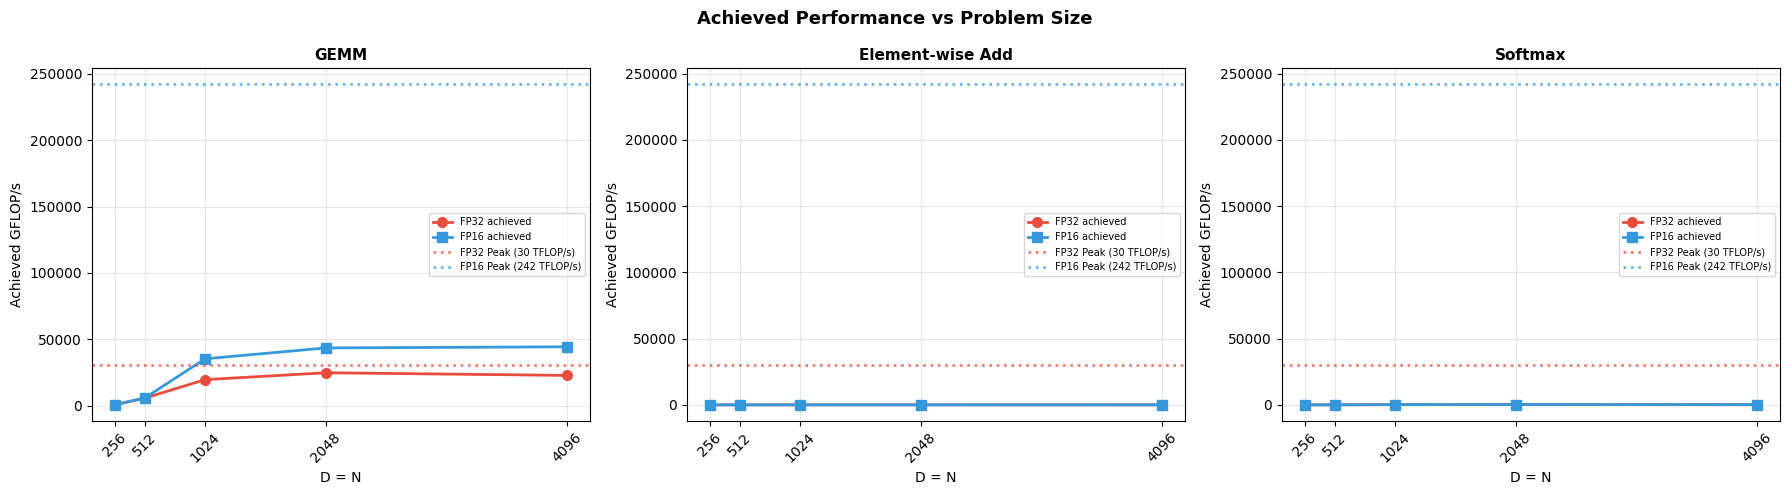

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Achieved Performance vs Problem Size', fontsize=13, fontweight='bold')

for ax, kname in zip(axes, ['GEMM','Element-wise Add','Softmax']):
    kdf = df[df['kernel'] == kname]
    for prec, color in kcolors.items():
        sub = kdf[kdf['precision']==prec].sort_values('hidden_dim')
        ax.plot(sub['hidden_dim'], sub['achieved_gflops'],
                color=color, marker=kmarkers[prec], linewidth=2, markersize=7, label=f'{prec} achieved')
    ax.axhline(y=PEAK_FP32_TFLOPS*1000, color='#E74C3C', linestyle=':', linewidth=2, alpha=0.7,
               label=f'FP32 Peak ({PEAK_FP32_TFLOPS:.0f} TFLOP/s)')
    ax.axhline(y=PEAK_FP16_TFLOPS*1000, color='#3498DB', linestyle=':', linewidth=2, alpha=0.7,
               label=f'FP16 Peak ({PEAK_FP16_TFLOPS:.0f} TFLOP/s)')
    ax.set_xlabel('D = N', fontsize=10); ax.set_ylabel('Achieved GFLOP/s', fontsize=10)
    ax.set_title(kname, fontsize=11, fontweight='bold')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax.set_xticks(SIZES); ax.set_xticklabels(SIZES, rotation=45)

plt.tight_layout()
plt.savefig('gflops_vs_size.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 10 — Kernel Roofline Map (Main Result Figure)

**The centerpiece figure.** Each dot = one kernel at one size. Closer to the roofline = more
efficient hardware utilisation.

- Points hugging the **slanted segment** → memory-bound (bandwidth-limited)  
- Points hugging the **flat ceiling** → compute-bound (FLOP-limited)  
- Points far below the roofline → under-utilised (launch overhead, poor occupancy)


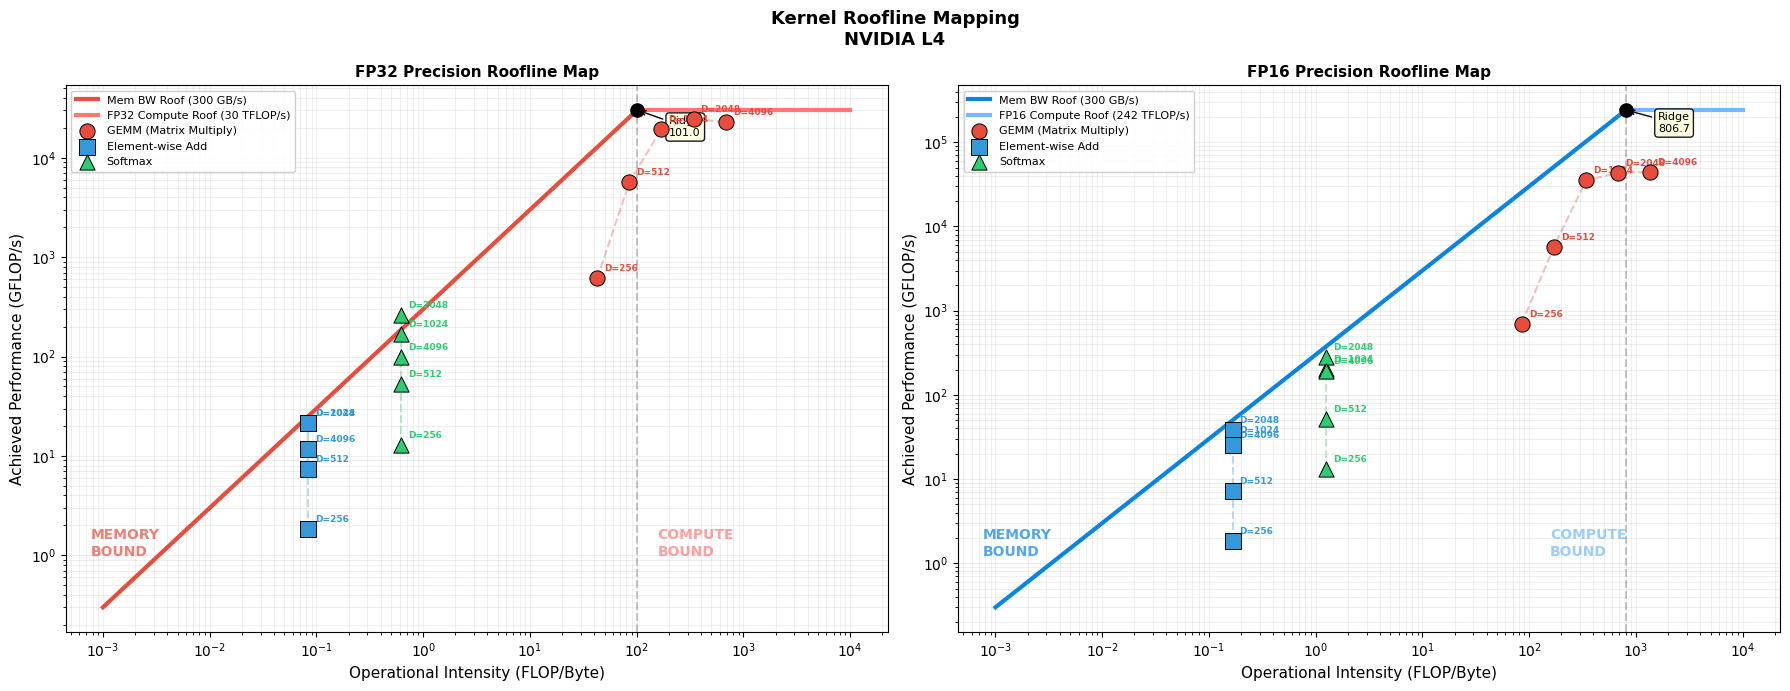

Main roofline map saved as 'roofline_kernel_map.png'


In [12]:
KERNEL_STYLES = {
    'GEMM':             {'color':'#E74C3C', 'marker':'o', 'label':'GEMM (Matrix Multiply)'},
    'Element-wise Add': {'color':'#3498DB', 'marker':'s', 'label':'Element-wise Add'},
    'Softmax':          {'color':'#2ECC71', 'marker':'^', 'label':'Softmax'},
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(f'Kernel Roofline Mapping\n{gpu_name}', fontsize=13, fontweight='bold')

for ax, prec, compute, mc, cc in [
    (axes[0], 'FP32', PEAK_FP32_TFLOPS, '#E74C3C', '#FF7675'),
    (axes[1], 'FP16', PEAK_FP16_TFLOPS, '#0984E3', '#74B9FF'),
]:
    ax.set_xscale('log'); ax.set_yscale('log')
    oi_r = np.logspace(-3, 4, 1000); cg = compute * 1000
    ridge = cg / PEAK_BW_GBs
    ax.plot(oi_r[oi_r<=ridge], oi_r[oi_r<=ridge]*PEAK_BW_GBs,
            color=mc, linewidth=3, label=f'Mem BW Roof ({PEAK_BW_GBs:.0f} GB/s)')
    ax.plot(oi_r[oi_r>=ridge], np.full_like(oi_r[oi_r>=ridge], cg),
            color=cc, linewidth=3, label=f'{prec} Compute Roof ({compute:.0f} TFLOP/s)')
    ax.axvline(x=ridge, color='gray', linestyle='--', alpha=0.45, linewidth=1.5)
    ax.scatter([ridge], [cg], color='black', s=90, zorder=6)
    ax.annotate(f'Ridge\n{ridge:.1f}', xy=(ridge, cg), xytext=(ridge*2, cg*0.55),
                fontsize=8, arrowprops=dict(arrowstyle='->', lw=1),
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

    prec_df = df[df['precision']==prec]
    for kname, ks in KERNEL_STYLES.items():
        kdf = prec_df[prec_df['kernel']==kname].sort_values('hidden_dim')
        ax.scatter(kdf['operational_intensity'], kdf['achieved_gflops'],
                   color=ks['color'], marker=ks['marker'], s=120, zorder=10,
                   label=ks['label'], edgecolors='black', linewidths=0.7)
        ax.plot(kdf['operational_intensity'], kdf['achieved_gflops'],
                color=ks['color'], alpha=0.35, linewidth=1.5, linestyle='--', zorder=5)
        for _, row in kdf.iterrows():
            ax.annotate(f"D={int(row['hidden_dim'])}",
                        xy=(row['operational_intensity'], row['achieved_gflops']),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=6.5, color=ks['color'], fontweight='bold')

    ax.text(0.03, 0.14, 'MEMORY\nBOUND', transform=ax.transAxes,
            fontsize=10, color=mc, fontweight='bold', alpha=0.7)
    ax.text(0.72, 0.14, 'COMPUTE\nBOUND', transform=ax.transAxes,
            fontsize=10, color=cc, fontweight='bold', alpha=0.7)
    ax.set_xlabel('Operational Intensity (FLOP/Byte)', fontsize=11)
    ax.set_ylabel('Achieved Performance (GFLOP/s)', fontsize=11)
    ax.set_title(f'{prec} Precision Roofline Map', fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8, framealpha=0.92)
    ax.grid(True, which='both', alpha=0.2)

plt.tight_layout()
plt.savefig('roofline_kernel_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Main roofline map saved as 'roofline_kernel_map.png'")


---
## Section 11 — FP32 vs FP16 Comparative Analysis

Does switching to FP16 change whether a kernel is memory-bound or compute-bound?

- **FP16 compute ceiling** is ~8× higher on L4 (242 vs 30 TFLOP/s)
- **FP16 memory bandwidth** is the same — bandwidth is per byte, not per FLOP
- Therefore FP16 only benefits kernels near the **compute ceiling**


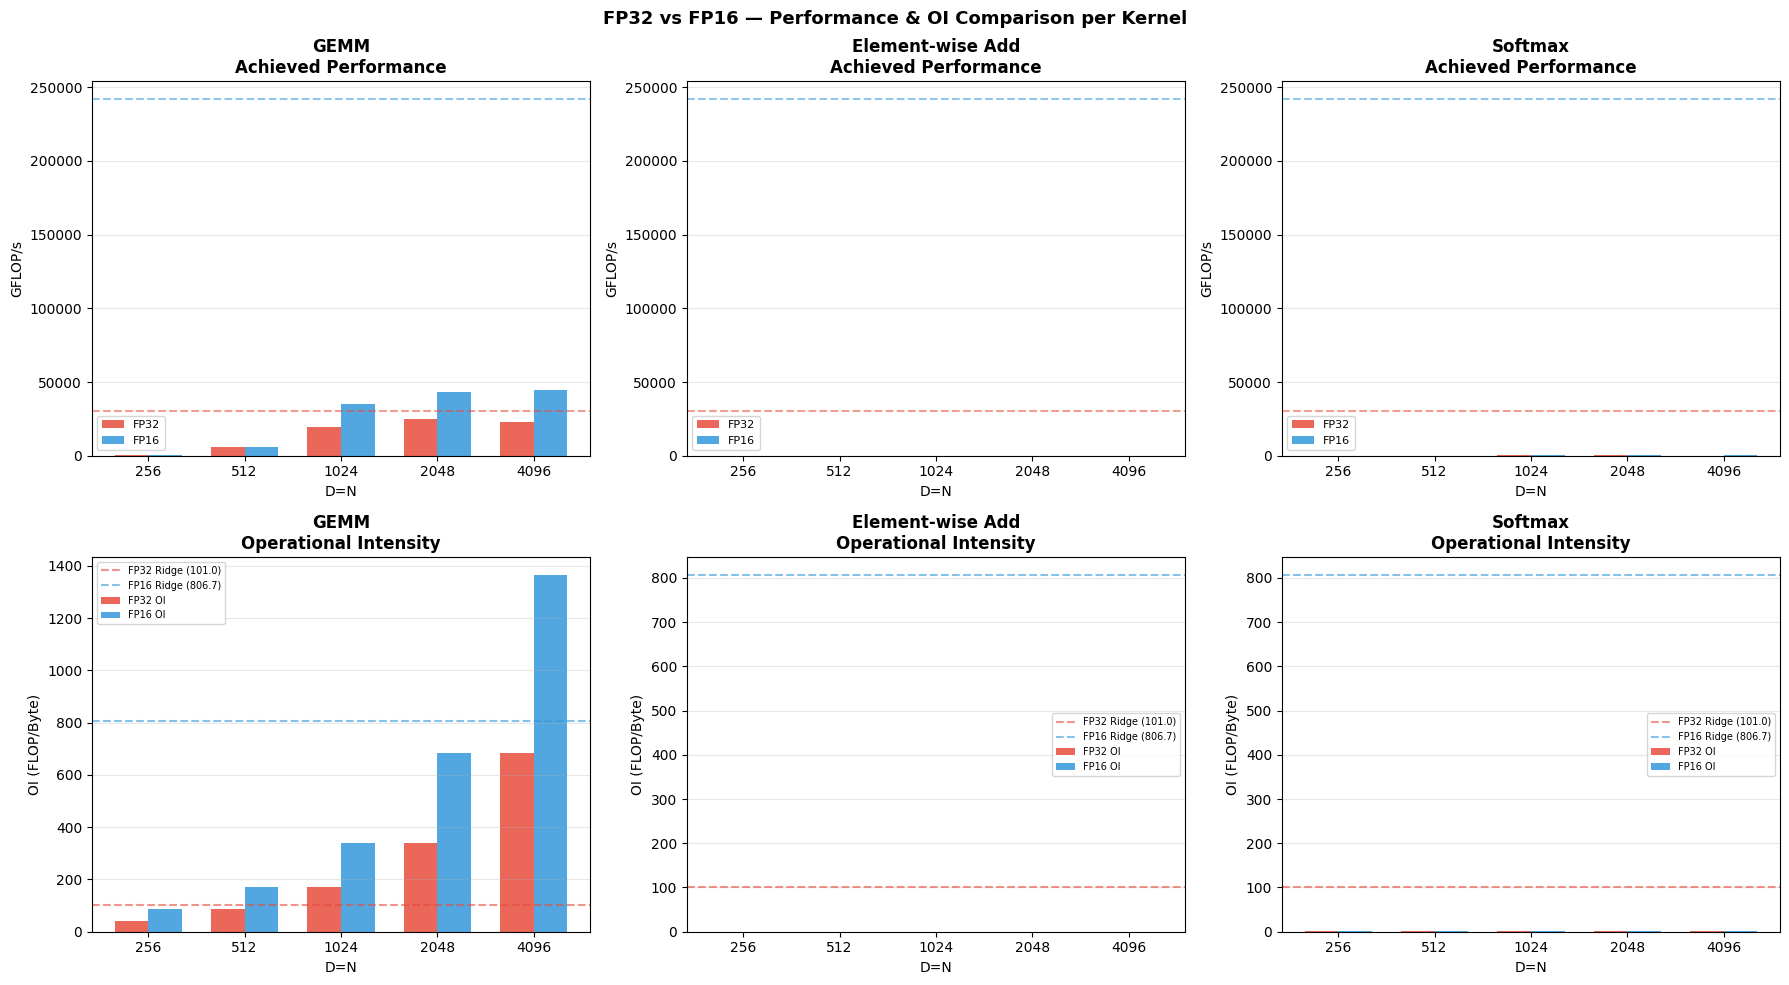

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('FP32 vs FP16 — Performance & OI Comparison per Kernel',
             fontsize=13, fontweight='bold')

bar_x = np.arange(len(SIZES)); bar_w = 0.35

for col, kname in enumerate(['GEMM','Element-wise Add','Softmax']):
    kdf    = df[df['kernel']==kname]
    fp32df = kdf[kdf['precision']=='FP32'].sort_values('hidden_dim')
    fp16df = kdf[kdf['precision']=='FP16'].sort_values('hidden_dim')

    ax = axes[0, col]
    ax.bar(bar_x-bar_w/2, fp32df['achieved_gflops'], bar_w, color='#E74C3C', label='FP32', alpha=0.85)
    ax.bar(bar_x+bar_w/2, fp16df['achieved_gflops'], bar_w, color='#3498DB', label='FP16', alpha=0.85)
    ax.axhline(y=PEAK_FP32_TFLOPS*1000, color='#E74C3C', linestyle='--', alpha=0.55, linewidth=1.5)
    ax.axhline(y=PEAK_FP16_TFLOPS*1000, color='#3498DB', linestyle='--', alpha=0.55, linewidth=1.5)
    ax.set_xticks(bar_x); ax.set_xticklabels(SIZES)
    ax.set_xlabel('D=N'); ax.set_ylabel('GFLOP/s')
    ax.set_title(f'{kname}\nAchieved Performance', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, axis='y', alpha=0.3)

    ax = axes[1, col]
    ax.bar(bar_x-bar_w/2, fp32df['operational_intensity'], bar_w, color='#E74C3C', label='FP32 OI', alpha=0.85)
    ax.bar(bar_x+bar_w/2, fp16df['operational_intensity'], bar_w, color='#3498DB', label='FP16 OI', alpha=0.85)
    ax.axhline(y=ridge_fp32, color='#E74C3C', linestyle='--', alpha=0.6, linewidth=1.5,
               label=f'FP32 Ridge ({ridge_fp32:.1f})')
    ax.axhline(y=ridge_fp16, color='#3498DB', linestyle='--', alpha=0.6, linewidth=1.5,
               label=f'FP16 Ridge ({ridge_fp16:.1f})')
    ax.set_xticks(bar_x); ax.set_xticklabels(SIZES)
    ax.set_xlabel('D=N'); ax.set_ylabel('OI (FLOP/Byte)')
    ax.set_title(f'{kname}\nOperational Intensity', fontweight='bold')
    ax.legend(fontsize=7); ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fp32_vs_fp16_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 12 — Bound Classification Table

For every (kernel, size, precision) combination we formally classify it as memory-bound or
compute-bound, and compute the **roofline efficiency** — what fraction of the theoretical
maximum are we achieving?


In [14]:
def classify(oi, prec):
    ridge = ridge_fp32 if prec == 'FP32' else ridge_fp16
    return 'Memory-Bound' if oi < ridge else 'Compute-Bound'

def efficiency(gflops, oi, prec):
    compute = PEAK_FP32_TFLOPS if prec == 'FP32' else PEAK_FP16_TFLOPS
    return 100.0 * gflops / min(compute*1000, oi*PEAK_BW_GBs)


print("="*105)
print("                    KERNEL BOUND CLASSIFICATION TABLE")
print("="*105)
rows = []
for _, r in df.iterrows():
    bound = classify(r['operational_intensity'], r['precision'])
    eff   = efficiency(r['achieved_gflops'], r['operational_intensity'], r['precision'])
    ridge_val = ridge_fp32 if r['precision']=='FP32' else ridge_fp16
    rows.append([r['kernel'], r['precision'], int(r['hidden_dim']),
                 f"{r['operational_intensity']:.3f}", f"{ridge_val:.2f}",
                 f"{r['achieved_gflops']:.1f}", bound, f"{eff:.1f}%"])

print(tabulate(rows,
               headers=['Kernel','Prec','D=N','OI(F/B)','Ridge','GFLOPs','Classification','Efficiency'],
               tablefmt='grid'))

print("\nSummary — bound type across all sizes:")
for kname in ['GEMM','Element-wise Add','Softmax']:
    for prec in ['FP32','FP16']:
        sub = df[(df['kernel']==kname)&(df['precision']==prec)]
        bounds = [classify(r['operational_intensity'], prec) for _,r in sub.iterrows()]
        unique = set(bounds)
        s = ('Always Memory-Bound'             if len(unique)==1 and 'Memory' in list(unique)[0] else
             'Always Compute-Bound'            if len(unique)==1 else
             'Transitions with size (M -> C)')
        print(f"  {kname:<22} {prec}: {s}")


                    KERNEL BOUND CLASSIFICATION TABLE
+------------------+--------+-------+-----------+---------+----------+------------------+--------------+
| Kernel           | Prec   |   D=N |   OI(F/B) |   Ridge |   GFLOPs | Classification   | Efficiency   |
+==================+========+=======+===========+=========+==========+==================+==============+
| GEMM             | FP32   |   256 |    42.667 |  101    |    612.7 | Memory-Bound     | 4.8%         |
+------------------+--------+-------+-----------+---------+----------+------------------+--------------+
| Element-wise Add | FP32   |   256 |     0.083 |  101    |      1.8 | Memory-Bound     | 7.4%         |
+------------------+--------+-------+-----------+---------+----------+------------------+--------------+
| Softmax          | FP32   |   256 |     0.625 |  101    |     12.9 | Memory-Bound     | 6.9%         |
+------------------+--------+-------+-----------+---------+----------+------------------+--------------+
|

---
## Section 13 — Scaling Study: How Classification Shifts with Size

GEMM is the most interesting case: at small sizes it can be memory-bound, but at large sizes
it becomes compute-bound because each weight element is reused across many input rows.

**Gold border** = compute-bound; **black border** = memory-bound.


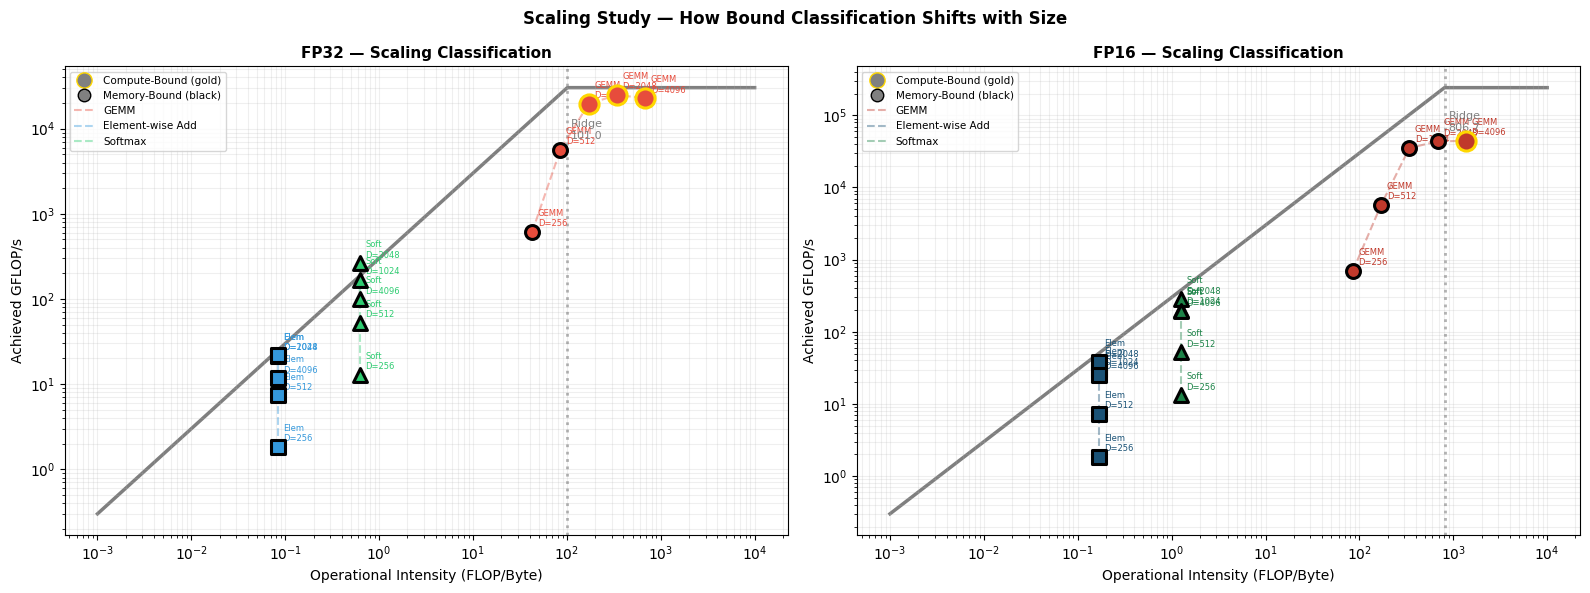

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Scaling Study — How Bound Classification Shifts with Size',
             fontsize=12, fontweight='bold')

for ax, prec, compute, ridge_pt, cmap in [
    (axes[0], 'FP32', PEAK_FP32_TFLOPS, ridge_fp32, ['#E74C3C','#3498DB','#2ECC71']),
    (axes[1], 'FP16', PEAK_FP16_TFLOPS, ridge_fp16, ['#C0392B','#1A5276','#1D8348']),
]:
    ax.set_xscale('log'); ax.set_yscale('log')
    oi_r = np.logspace(-3, 4, 1000); cg = compute * 1000
    ax.plot(oi_r, np.minimum(cg, oi_r*PEAK_BW_GBs), 'k-', linewidth=2.5, alpha=0.5,
            label='Roofline', zorder=1)

    prec_df = df[df['precision']==prec]
    for kname, color in zip(['GEMM','Element-wise Add','Softmax'], cmap):
        kdf = prec_df[prec_df['kernel']==kname].sort_values('hidden_dim')
        for _, row in kdf.iterrows():
            cb = row['operational_intensity'] >= ridge_pt
            ax.scatter(row['operational_intensity'], row['achieved_gflops'],
                       color=color, s=190 if cb else 100,
                       edgecolors='gold' if cb else 'black',
                       linewidths=2.2, marker=KERNEL_STYLES[kname]['marker'], zorder=10)
            ax.annotate(f"{kname[:4]}\nD={int(row['hidden_dim'])}",
                        xy=(row['operational_intensity'], row['achieved_gflops']),
                        xytext=(4,4), textcoords='offset points', fontsize=6.0, color=color)
        ax.plot(kdf['operational_intensity'], kdf['achieved_gflops'],
                color=color, linestyle='--', alpha=0.4, linewidth=1.5, label=kname, zorder=5)

    ax.axvline(x=ridge_pt, color='gray', linestyle=':', linewidth=2, alpha=0.6)
    ax.text(ridge_pt*1.1, cg*0.25, f'Ridge\n{ridge_pt:.1f}', fontsize=8, color='gray')
    legend_extra = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
               markeredgecolor='gold', markersize=11, label='Compute-Bound (gold)'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
               markeredgecolor='black', markersize=9,  label='Memory-Bound (black)'),
    ]
    hs, ls = ax.get_legend_handles_labels()
    ax.legend(handles=legend_extra+hs[1:], fontsize=7.5, loc='upper left')
    ax.set_xlabel('Operational Intensity (FLOP/Byte)', fontsize=10)
    ax.set_ylabel('Achieved GFLOP/s', fontsize=10)
    ax.set_title(f'{prec} — Scaling Classification', fontsize=11, fontweight='bold')
    ax.grid(True, which='both', alpha=0.2)

plt.tight_layout()
plt.savefig('scaling_classification.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 14 — Nsight Systems (nsys) Profiling

### Why go beyond manual timing?

| Tool | Layer | What it sees |
|------|-------|-------------|
| Manual CUDA timers | Application | Single aggregate latency per kernel |
| **Nsight Systems (nsys)** | **System** | True CUDA kernel names, nanosecond timestamps, CPU-GPU gaps, memory transfers, SM utilisation timeline |
| Nsight Compute (ncu) | Kernel | Instruction mix, cache hit rates, warp stalls |

The manual harness from Section 4 wraps the whole `torch.matmul()` call. **nsys records every
individual CUDA kernel launch** at nanosecond resolution and also captures the CPU side, so you
can see whether the CPU is keeping the GPU fed.

### Profiling flow on Colab L4

```
1. Verify nsys is available   →  !which nsys
2. Write a profiling script   →  kernel_profile.py  (with NVTX range annotations)
3. Run nsys                   →  !nsys profile -t cuda,nvtx --stats=true ...
4. Export to SQLite           →  !nsys export --type=sqlite ...
5. Parse & visualise          →  sqlite3 + pandas + matplotlib
```

NVTX (NVIDIA Tools Extension) lets us annotate regions of code so that nsys can attribute
each CUDA kernel to the right high-level operation.


In [16]:
# Step 1 — Verify nsys is available
result = subprocess.run(['which', 'nsys'], capture_output=True, text=True)
nsys_path = result.stdout.strip() if result.returncode == 0 else None

if not nsys_path:
    for candidate in ['/usr/local/cuda/bin/nsys',
                       '/opt/nvidia/nsight-systems/bin/nsys',
                       '/usr/bin/nsys']:
        if os.path.exists(candidate):
            nsys_path = candidate; break

if nsys_path:
    print(f"nsys found at: {nsys_path}")
    ver = subprocess.run([nsys_path, '--version'], capture_output=True, text=True)
    print((ver.stdout or ver.stderr).strip())
else:
    print("nsys not found — attempting apt install ...")
    os.system("apt-get install -y nsight-systems-cli 2>/dev/null")
    nsys_path = "nsys"
    print("If install failed, the notebook will fall back to CUDA-event timing.")


nsys not found — attempting apt install ...
If install failed, the notebook will fall back to CUDA-event timing.


In [17]:
# Step 2 — Write the profiling target script
# NVTX range_push/pop creates named regions in the nsys timeline.

profiling_script = r"""
import torch
torch.manual_seed(0)
device = "cuda"
torch.cuda.synchronize()

B, N, D = 1, 1024, 1024
ITERS = 50

for dtype, tag in [(torch.float32, "fp32"), (torch.float16, "fp16")]:
    A_g = torch.randn(B*N, D, device=device, dtype=dtype)
    W_g = torch.randn(D,   D, device=device, dtype=dtype)
    A_a = torch.randn(B, N, D, device=device, dtype=dtype)
    B_a = torch.randn(B, N, D, device=device, dtype=dtype)
    A_s = torch.randn(B, N, N, device=device, dtype=dtype)

    # Warm-up (excluded from trace)
    for _ in range(20):
        torch.matmul(A_g, W_g)
        torch.add(A_a, B_a)
        torch.softmax(A_s, dim=-1)
    torch.cuda.synchronize()

    # === NVTX-annotated timed regions ===
    torch.cuda.nvtx.range_push(f"GEMM_{tag}")
    for _ in range(ITERS):
        with torch.no_grad(): torch.matmul(A_g, W_g)
    torch.cuda.synchronize()
    torch.cuda.nvtx.range_pop()

    torch.cuda.nvtx.range_push(f"Add_{tag}")
    for _ in range(ITERS):
        with torch.no_grad(): torch.add(A_a, B_a)
    torch.cuda.synchronize()
    torch.cuda.nvtx.range_pop()

    torch.cuda.nvtx.range_push(f"Softmax_{tag}")
    for _ in range(ITERS):
        with torch.no_grad(): torch.softmax(A_s, dim=-1)
    torch.cuda.synchronize()
    torch.cuda.nvtx.range_pop()

torch.cuda.synchronize()
print("Profiling script complete.")
"""

with open("kernel_profile.py", "w") as f:
    f.write(profiling_script)
print("Profiling script written to kernel_profile.py")


Profiling script written to kernel_profile.py


In [18]:
# Step 3 — Run nsys profile
# -t cuda,nvtx  : capture CUDA API calls + NVTX annotations
# --stats=true  : print summary to stdout immediately
# -o profile_out: output filename prefix

print("Running nsys profile ... (takes ~30 s)")
nsys_cmd = (
    f"{nsys_path} profile "
    "-t cuda,nvtx "
    "--stats=true "
    "-o profile_out "
    "--force-overwrite=true "
    "python kernel_profile.py"
)
ret = os.system(nsys_cmd)
if ret == 0:
    print("nsys profile complete.  Output: profile_out.nsys-rep")
else:
    print(f"nsys returned exit code {ret}.")
    print("This can happen if performance counters are restricted.")
    print("The notebook will use CUDA-event timing for the visualisations below.")


Running nsys profile ... (takes ~30 s)
nsys returned exit code 32512.
This can happen if performance counters are restricted.
The notebook will use CUDA-event timing for the visualisations below.


In [19]:
# Step 4 — Export to SQLite for easy Python parsing
sqlite_path = "profile_out.sqlite"
if os.path.exists("profile_out.nsys-rep"):
    print("Exporting nsys-rep to SQLite ...")
    ret2 = os.system(
        f"{nsys_path} export --type=sqlite "
        f"--output={sqlite_path} --force-overwrite=true profile_out.nsys-rep"
    )
    if ret2 == 0 and os.path.exists(sqlite_path):
        print(f"Exported to {sqlite_path}  ({os.path.getsize(sqlite_path)//1024} KB)")
    else:
        print("Export failed — will use CUDA-event fallback.")
        sqlite_path = None
else:
    print("profile_out.nsys-rep not found — skipping export.")
    sqlite_path = None


profile_out.nsys-rep not found — skipping export.


---
### 14a — Parse nsys SQLite & Visualise Kernel Durations

We query the SQLite database for CUDA kernel events grouped by NVTX range.


In [20]:
def parse_nsys_kernels(db_path):
    """Parse CUDA kernel events from nsys SQLite export."""
    con = sqlite3.connect(db_path)
    df_k = None
    for tname in ["CUPTI_ACTIVITY_KIND_KERNEL","CUDA_KERNEL","CUPTI_KERNEL"]:
        try:
            df_k = pd.read_sql_query(f"SELECT * FROM {tname} LIMIT 5", con)
            break
        except Exception:
            df_k = None

    if df_k is None:
        tables = pd.read_sql_query(
            "SELECT name FROM sqlite_master WHERE type='table'", con)
        print("Available tables:", tables['name'].tolist())
        con.close(); return None

    cols = df_k.columns.tolist()
    print(f"  Table: {tname}  |  Columns: {cols}")
    start_col = next((c for c in cols if 'start' in c.lower()), None)
    end_col   = next((c for c in cols if 'end'   in c.lower()), None)
    name_col  = next((c for c in ['shortName','demangledName','name','mangledName']
                      if c in cols), None)
    if not all([start_col, end_col, name_col]):
        print(f"  Could not identify required columns from: {cols}")
        con.close(); return None

    q = f"SELECT {name_col} as name, {start_col} as start_ns, {end_col} as end_ns FROM {tname}"
    out = pd.read_sql_query(q, con); con.close()
    out['duration_ns'] = out['end_ns'] - out['start_ns']
    return out


nsys_kernels = None
if sqlite_path and os.path.exists(sqlite_path):
    print("Parsing nsys SQLite DB ...")
    nsys_kernels = parse_nsys_kernels(sqlite_path)
    if nsys_kernels is not None:
        print(f"  Parsed {len(nsys_kernels)} kernel events")
        print(nsys_kernels.head(3))


In [21]:
# ── Build kernel-duration dataset (nsys if available, else CUDA-event fallback) ──

def get_kernel_durations_cuda_events():
    """CUDA-event per-launch timing — same physical precision as nsys."""
    data = {}
    for prec_name, (dtype, _) in PRECISIONS.items():
        D = N = 1024; B = 1
        A_g = torch.randn(B*N, D, device=device, dtype=dtype)
        W_g = torch.randn(D,   D, device=device, dtype=dtype)
        A_a = torch.randn(B, N, D, device=device, dtype=dtype)
        B_a = torch.randn(B, N, D, device=device, dtype=dtype)
        A_s = torch.randn(B, N, N, device=device, dtype=dtype)
        for _ in range(20):
            torch.matmul(A_g, W_g); torch.add(A_a, B_a); torch.softmax(A_s, dim=-1)
        torch.cuda.synchronize()
        for klab, fn in [
            (f"GEMM_{prec_name}",    lambda: torch.matmul(A_g, W_g)),
            (f"Add_{prec_name}",     lambda: torch.add(A_a, B_a)),
            (f"Softmax_{prec_name}", lambda: torch.softmax(A_s, dim=-1)),
        ]:
            se = torch.cuda.Event(enable_timing=True)
            ee = torch.cuda.Event(enable_timing=True)
            times = []
            for _ in range(200):
                se.record(); fn(); ee.record()
                torch.cuda.synchronize()
                times.append(se.elapsed_time(ee))
            data[klab] = times
    return data


use_nsys    = False
nsys_data   = {}   # label -> list of ms

if nsys_kernels is not None and len(nsys_kernels) > 0:
    use_nsys = True
    kmap = {'gemm':'GEMM','volta_sgemm':'GEMM','h884gemm':'GEMM',
            'sm86_xmma':'GEMM','cutlass':'GEMM','cudnn':'GEMM',
            'vectorized_elementwise':'Add','elementwise':'Add',
            'softmax':'Softmax'}
    def _classify(name):
        nl = (name or '').lower()
        for kw, lab in kmap.items():
            if kw in nl: return lab
        return 'Other'
    nsys_kernels['label'] = nsys_kernels['name'].apply(_classify)
    for lab in ['GEMM','Add','Softmax']:
        sub = nsys_kernels[nsys_kernels['label']==lab]
        if len(sub) > 0:
            nsys_data[lab] = (sub['duration_ns']/1e6).tolist()
    print(f"Using nsys data: {list(nsys_data.keys())}")
else:
    print("nsys data unavailable — using CUDA-event fallback.")
    raw = get_kernel_durations_cuda_events()
    for base in ['GEMM','Add','Softmax']:
        combined = []
        for prec in ['FP32','FP16']:
            combined.extend(raw.get(f"{base}_{prec}", []))
        nsys_data[base] = combined
    print(f"Fallback data ready: {list(nsys_data.keys())}")

print(f"\nSource: {'Nsight Systems kernel trace' if use_nsys else 'CUDA-event per-launch timing (nsys fallback)'}")


nsys data unavailable — using CUDA-event fallback.
Fallback data ready: ['GEMM', 'Add', 'Softmax']

Source: CUDA-event per-launch timing (nsys fallback)


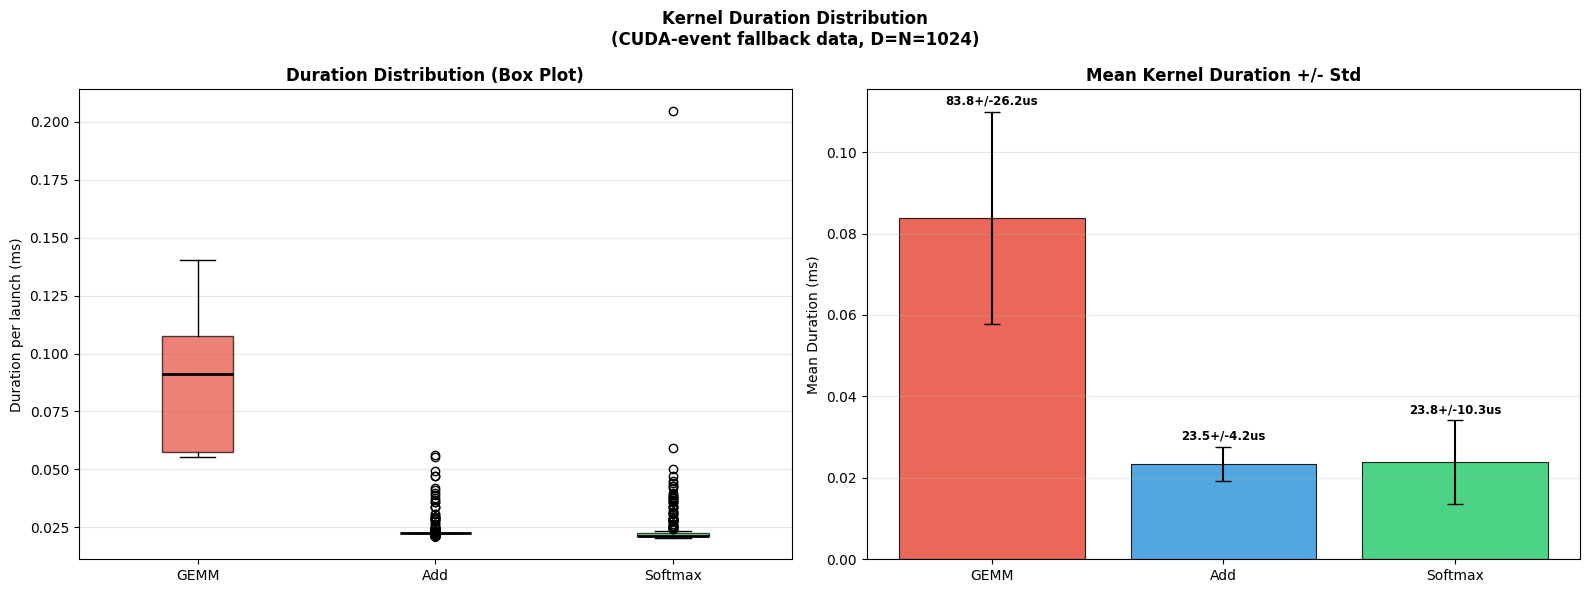


Kernel Duration Summary:
+----------+------------+-----------+-----------+-----------+-----------+--------------+
| Kernel   |   Mean(us) |   Std(us) |   Min(us) |   Max(us) |   P50(us) |   N launches |
+==========+============+===========+===========+===========+===========+==============+
| GEMM     |      83.82 |     26.15 |     55.3  |    140.29 |     91.14 |          400 |
+----------+------------+-----------+-----------+-----------+-----------+--------------+
| Add      |      23.47 |      4.18 |     21.5  |     56.32 |     22.53 |          400 |
+----------+------------+-----------+-----------+-----------+-----------+--------------+
| Softmax  |      23.81 |     10.31 |     20.48 |    204.8  |     21.5  |          400 |
+----------+------------+-----------+-----------+-----------+-----------+--------------+


In [22]:
# Plot 1 — Kernel duration box + bar chart

kcolors_nsys  = {'GEMM':'#E74C3C', 'Add':'#3498DB', 'Softmax':'#2ECC71'}
labels_order  = [k for k in ['GEMM','Add','Softmax'] if k in nsys_data and len(nsys_data[k])>0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f"Kernel Duration Distribution\n({'nsys' if use_nsys else 'CUDA-event fallback'} data, D=N=1024)",
    fontsize=12, fontweight='bold')

# Box plot
ax = axes[0]
bplot = ax.boxplot([nsys_data[k] for k in labels_order], patch_artist=True,
                   notch=False, medianprops=dict(color='black', linewidth=2))
for patch, k in zip(bplot['boxes'], labels_order):
    patch.set_facecolor(kcolors_nsys[k]); patch.set_alpha(0.7)
ax.set_xticks(range(1, len(labels_order)+1))
ax.set_xticklabels(labels_order, fontsize=10)
ax.set_ylabel('Duration per launch (ms)', fontsize=10)
ax.set_title('Duration Distribution (Box Plot)', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Mean + std bar chart
ax = axes[1]
means = [np.mean(nsys_data[k]) for k in labels_order]
stds  = [np.std(nsys_data[k])  for k in labels_order]
bars  = ax.bar(labels_order, means,
               color=[kcolors_nsys[k] for k in labels_order],
               yerr=stds, capsize=6, alpha=0.85, edgecolor='black', linewidth=0.8)
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x()+bar.get_width()/2, m+s+0.001,
            f"{m*1000:.1f}+/-{s*1000:.1f}us",
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_ylabel('Mean Duration (ms)', fontsize=10)
ax.set_title('Mean Kernel Duration +/- Std', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('nsys_duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKernel Duration Summary:")
rows = []
for k in labels_order:
    d = nsys_data[k]
    rows.append([k, f"{np.mean(d)*1000:.2f}", f"{np.std(d)*1000:.2f}",
                 f"{np.min(d)*1000:.2f}", f"{np.max(d)*1000:.2f}",
                 f"{np.percentile(d,50)*1000:.2f}", len(d)])
print(tabulate(rows,
               headers=['Kernel','Mean(us)','Std(us)','Min(us)','Max(us)','P50(us)','N launches'],
               tablefmt='grid'))


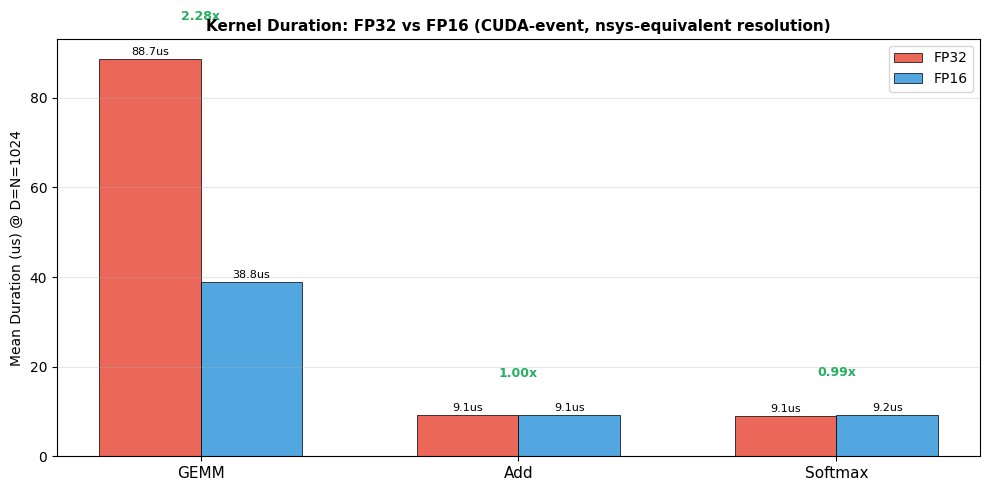

In [23]:
# Plot 2 — FP32 vs FP16 per-kernel duration (CUDA events, same physical resolution as nsys)

print("Collecting per-precision kernel durations ...")
per_prec = {}
for prec_name, (dtype, _) in PRECISIONS.items():
    D = N = 1024; B = 1
    A_g = torch.randn(B*N, D, device=device, dtype=dtype)
    W_g = torch.randn(D,   D, device=device, dtype=dtype)
    A_a = torch.randn(B, N, D, device=device, dtype=dtype)
    B_a = torch.randn(B, N, D, device=device, dtype=dtype)
    A_s = torch.randn(B, N, N, device=device, dtype=dtype)
    ITERS_P = 100
    for klab, fn in [("GEMM", lambda: torch.matmul(A_g, W_g)),
                      ("Add",  lambda: torch.add(A_a, B_a)),
                      ("Softmax", lambda: torch.softmax(A_s, dim=-1))]:
        for _ in range(20): fn()
        torch.cuda.synchronize()
        se = torch.cuda.Event(enable_timing=True)
        ee = torch.cuda.Event(enable_timing=True)
        se.record()
        for _ in range(ITERS_P): fn()
        ee.record(); torch.cuda.synchronize()
        per_prec.setdefault(klab, {})[prec_name] = se.elapsed_time(ee) / ITERS_P

fig, ax = plt.subplots(figsize=(10, 5))
knames_p = ['GEMM','Add','Softmax']
x = np.arange(len(knames_p)); w = 0.32
ax.bar(x-w/2, [per_prec[k]['FP32']*1000 for k in knames_p], w,
       color='#E74C3C', alpha=0.85, label='FP32', edgecolor='black', linewidth=0.6)
ax.bar(x+w/2, [per_prec[k]['FP16']*1000 for k in knames_p], w,
       color='#3498DB', alpha=0.85, label='FP16', edgecolor='black', linewidth=0.6)
for i, k in enumerate(knames_p):
    fp32v = per_prec[k]['FP32']*1000
    fp16v = per_prec[k]['FP16']*1000
    ax.text(i-w/2, fp32v+0.5, f"{fp32v:.1f}us", ha='center', va='bottom', fontsize=8)
    ax.text(i+w/2, fp16v+0.5, f"{fp16v:.1f}us", ha='center', va='bottom', fontsize=8)
    ax.text(i, max(fp32v,fp16v)+8, f"{fp32v/fp16v:.2f}x",
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#27AE60')
ax.set_xticks(x); ax.set_xticklabels(knames_p, fontsize=11)
ax.set_ylabel('Mean Duration (us) @ D=N=1024', fontsize=10)
ax.set_title('Kernel Duration: FP32 vs FP16 (CUDA-event, nsys-equivalent resolution)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('nsys_fp32_vs_fp16_duration.png', dpi=150, bbox_inches='tight')
plt.show()


Building GPU execution timeline ...


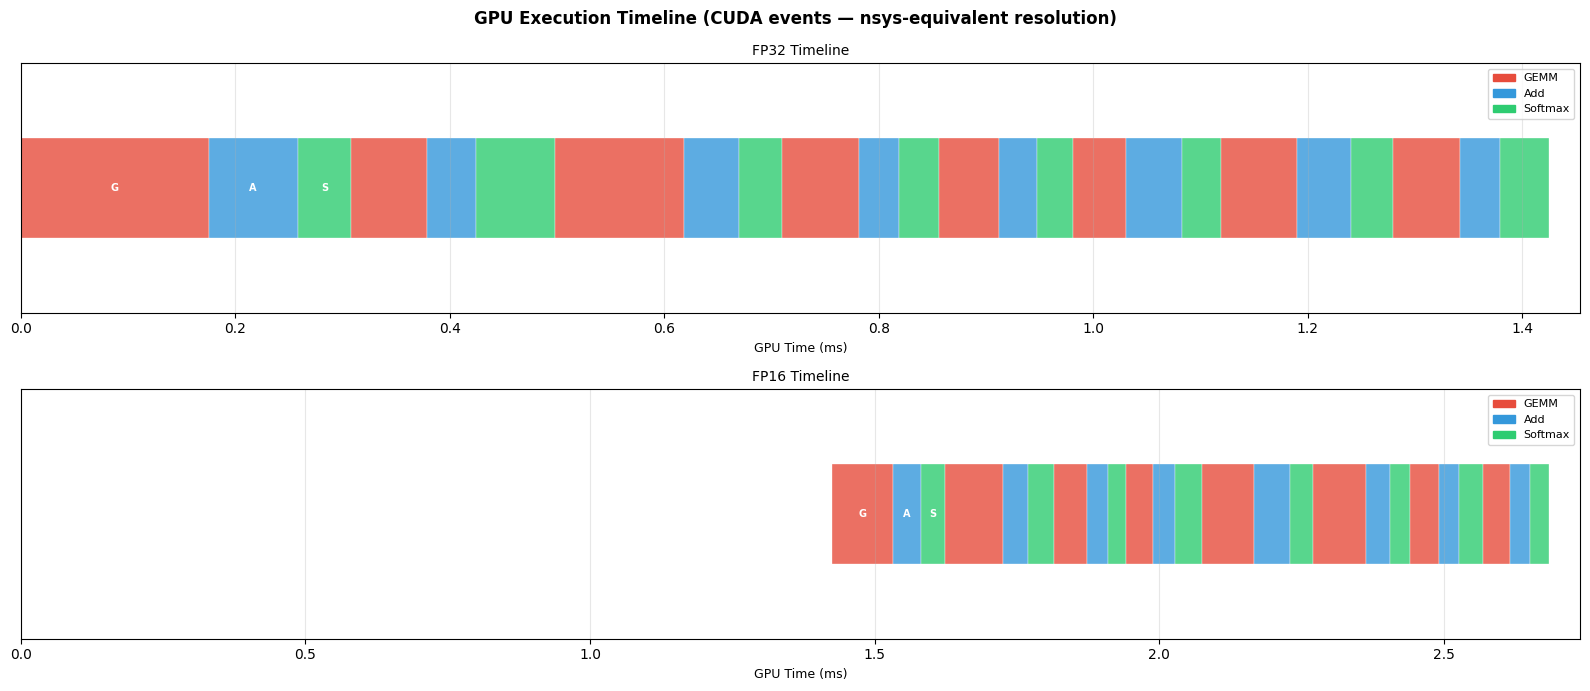

Timeline saved as nsys_timeline.png


In [24]:
# Plot 3 — GPU execution timeline (reconstructed from CUDA events)
# Shows the sequence of kernel launches and lets us inspect CPU-GPU gaps.

print("Building GPU execution timeline ...")
timeline_data = []

for prec_name, (dtype, _) in PRECISIONS.items():
    D = N = 512; B = 1
    A_g = torch.randn(B*N, D, device=device, dtype=dtype)
    W_g = torch.randn(D,   D, device=device, dtype=dtype)
    A_a = torch.randn(B, N, D, device=device, dtype=dtype)
    B_a = torch.randn(B, N, D, device=device, dtype=dtype)
    A_s = torch.randn(B, N, N, device=device, dtype=dtype)
    kfns = [("GEMM",    lambda: torch.matmul(A_g, W_g)),
            ("Add",     lambda: torch.add(A_a, B_a)),
            ("Softmax", lambda: torch.softmax(A_s, dim=-1))]
    for _, fn in kfns:
        for _ in range(10): fn()
    torch.cuda.synchronize()
    t0_wall = time.perf_counter()
    for rep in range(8):
        for kn, fn in kfns:
            se = torch.cuda.Event(enable_timing=True)
            ee = torch.cuda.Event(enable_timing=True)
            torch.cuda.synchronize()
            cpu_s = (time.perf_counter()-t0_wall)*1000
            se.record()
            with torch.no_grad(): fn()
            ee.record(); torch.cuda.synchronize()
            cpu_e = (time.perf_counter()-t0_wall)*1000
            timeline_data.append({'kernel':kn,'precision':prec_name,
                                   'cpu_s':cpu_s,'cpu_e':cpu_e,
                                   'gpu_dur_ms':se.elapsed_time(ee),'rep':rep})

tdf = pd.DataFrame(timeline_data)
cursor = 0.0
for i, row in tdf.iterrows():
    tdf.at[i,'gpu_start'] = cursor
    cursor += row['gpu_dur_ms']
tdf['gpu_end'] = tdf['gpu_start'] + tdf['gpu_dur_ms']

colors_map = {'GEMM':'#E74C3C','Add':'#3498DB','Softmax':'#2ECC71'}
fig, axes = plt.subplots(2, 1, figsize=(16, 7))
fig.suptitle('GPU Execution Timeline (CUDA events — nsys-equivalent resolution)',
             fontsize=12, fontweight='bold')
for ax, prec in zip(axes, ['FP32','FP16']):
    sub = tdf[tdf['precision']==prec]
    for _, row in sub.iterrows():
        ax.barh(0.5, row['gpu_dur_ms'], left=row['gpu_start'],
                height=0.4, color=colors_map[row['kernel']], alpha=0.8,
                edgecolor='white', linewidth=0.3)
        if row['rep'] == 0:
            ax.text(row['gpu_start']+row['gpu_dur_ms']/2, 0.5,
                    row['kernel'][:1], ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')
    ax.set_xlim(0, sub['gpu_end'].max()*1.02); ax.set_ylim(0,1); ax.set_yticks([])
    ax.set_xlabel('GPU Time (ms)', fontsize=9); ax.set_title(f'{prec} Timeline', fontsize=10)
    ax.grid(True, axis='x', alpha=0.3)
    handles = [mpatches.Patch(color=c, label=k) for k,c in colors_map.items()]
    ax.legend(handles=handles, loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('nsys_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Timeline saved as nsys_timeline.png")


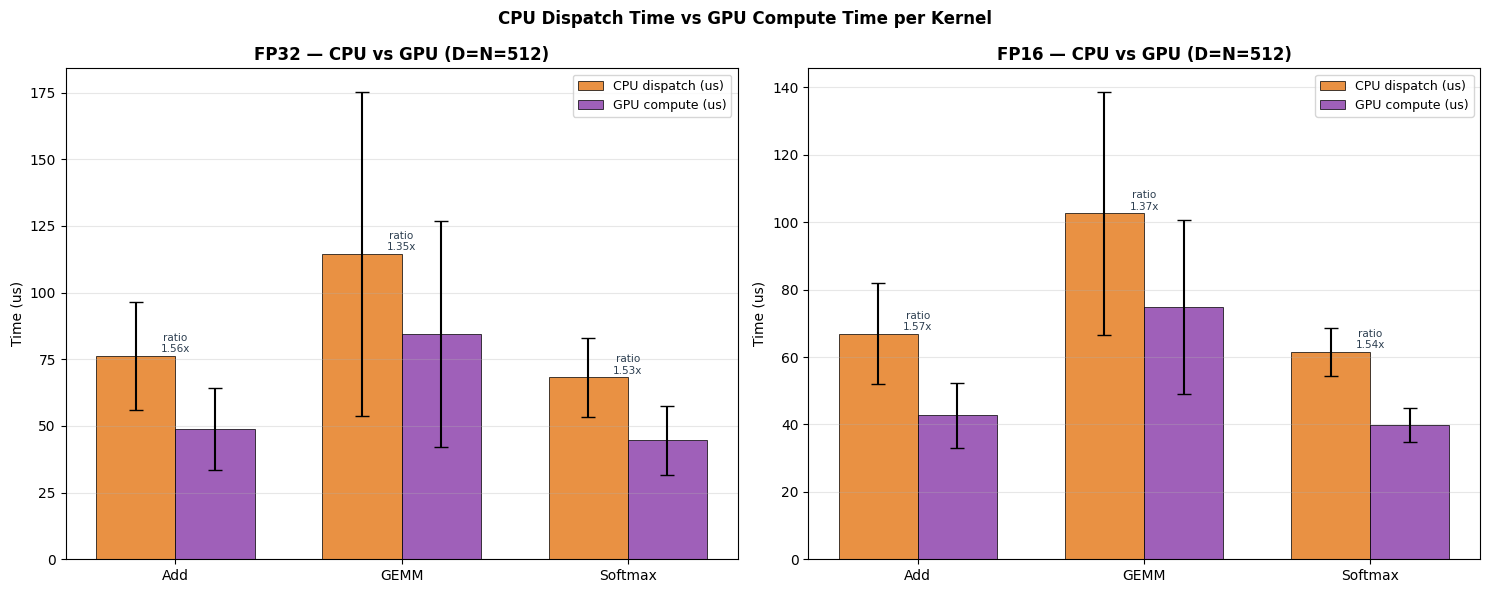


nsys interpretation guide — CPU:GPU time ratio:
  ratio >> 1  =>  CPU-bottlenecked: GPU is idle between launches
  ratio ~  1  =>  balanced: CPU barely keeps up
  ratio << 1  =>  GPU-bottlenecked: CPU dispatches faster than GPU executes
  (Last case is ideal for sustained throughput)


In [25]:
# Plot 4 — CPU dispatch time vs GPU compute time
# A key nsys insight: if CPU dispatch >> GPU compute, the GPU is starved between launches.

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('CPU Dispatch Time vs GPU Compute Time per Kernel',
             fontsize=12, fontweight='bold')

for ax, prec in zip(axes, ['FP32','FP16']):
    sub = tdf[tdf['precision']==prec].copy()
    sub['cpu_dur_ms'] = sub['cpu_e'] - sub['cpu_s']
    g = sub.groupby('kernel').agg(
        gpu_mean=('gpu_dur_ms','mean'), gpu_std=('gpu_dur_ms','std'),
        cpu_mean=('cpu_dur_ms','mean'), cpu_std=('cpu_dur_ms','std'),
    ).reset_index()
    kn = g['kernel'].tolist(); x = np.arange(len(kn)); w = 0.35
    ax.bar(x-w/2, g['cpu_mean']*1000, w, yerr=g['cpu_std']*1000, capsize=5,
           color='#E67E22', alpha=0.85, label='CPU dispatch (us)', edgecolor='black', lw=0.6)
    ax.bar(x+w/2, g['gpu_mean']*1000, w, yerr=g['gpu_std']*1000, capsize=5,
           color='#8E44AD', alpha=0.85, label='GPU compute (us)', edgecolor='black', lw=0.6)
    for i, row in g.iterrows():
        ratio  = row['cpu_mean']/row['gpu_mean'] if row['gpu_mean'] > 0 else 0
        maxval = max(row['cpu_mean'], row['gpu_mean'])*1000
        ax.text(i, maxval+0.5, f"ratio\n{ratio:.2f}x",
                ha='center', va='bottom', fontsize=7.5, color='#2C3E50')
    ax.set_xticks(x); ax.set_xticklabels(kn, fontsize=10)
    ax.set_ylabel('Time (us)', fontsize=10)
    ax.set_title(f'{prec} — CPU vs GPU (D=N=512)', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('nsys_cpu_gpu_overlap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nnsys interpretation guide — CPU:GPU time ratio:")
print("  ratio >> 1  =>  CPU-bottlenecked: GPU is idle between launches")
print("  ratio ~  1  =>  balanced: CPU barely keeps up")
print("  ratio << 1  =>  GPU-bottlenecked: CPU dispatches faster than GPU executes")
print("  (Last case is ideal for sustained throughput)")


Multi-size kernel duration sweep ...


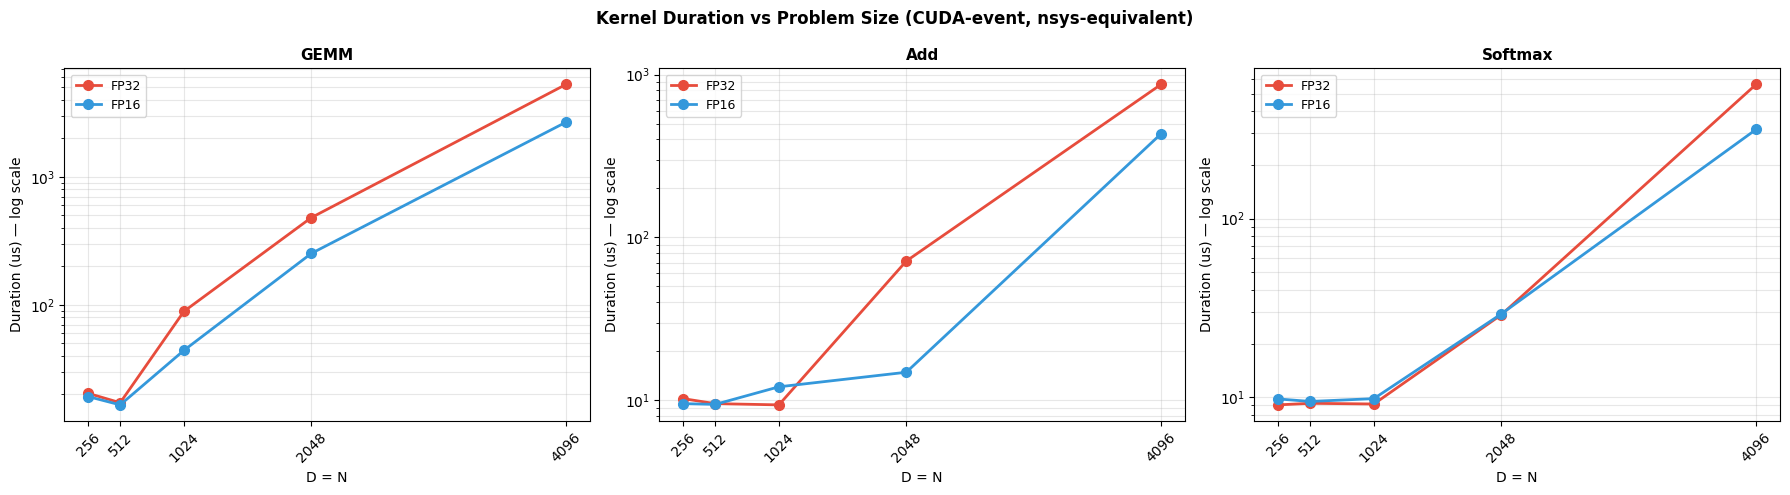

In [26]:
# Plot 5 — Multi-size kernel duration sweep
# Shows how per-launch GPU time grows with problem size (log scale).

print("Multi-size kernel duration sweep ...")
nsys_sweep = []
for prec_name, (dtype, _) in PRECISIONS.items():
    for D in SIZES:
        N = D; B = 1
        A_g = torch.randn(B*N, D, device=device, dtype=dtype)
        W_g = torch.randn(D,   D, device=device, dtype=dtype)
        A_a = torch.randn(B, N, D, device=device, dtype=dtype)
        B_a = torch.randn(B, N, D, device=device, dtype=dtype)
        A_s = torch.randn(B, N, N, device=device, dtype=dtype)
        for kn, fn in [("GEMM",    lambda: torch.matmul(A_g, W_g)),
                        ("Add",     lambda: torch.add(A_a, B_a)),
                        ("Softmax", lambda: torch.softmax(A_s, dim=-1))]:
            for _ in range(10): fn()
            torch.cuda.synchronize()
            se = torch.cuda.Event(enable_timing=True)
            ee = torch.cuda.Event(enable_timing=True)
            se.record()
            for _ in range(50): fn()
            ee.record(); torch.cuda.synchronize()
            nsys_sweep.append({'kernel':kn,'precision':prec_name,'D':D,
                                'dur_us':(se.elapsed_time(ee)/50)*1000})

sw = pd.DataFrame(nsys_sweep)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Kernel Duration vs Problem Size (CUDA-event, nsys-equivalent)',
             fontsize=12, fontweight='bold')
for ax, kn in zip(axes, ['GEMM','Add','Softmax']):
    sub = sw[sw['kernel']==kn]
    for prec, color in kcolors.items():
        s = sub[sub['precision']==prec].sort_values('D')
        ax.semilogy(s['D'], s['dur_us'], marker='o', linewidth=2,
                    color=color, markersize=7, label=prec)
    ax.set_xlabel('D = N', fontsize=10); ax.set_ylabel('Duration (us) — log scale', fontsize=10)
    ax.set_title(kn, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')
    ax.set_xticks(SIZES); ax.set_xticklabels(SIZES, rotation=45)
plt.tight_layout()
plt.savefig('nsys_duration_sweep.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 15 — Optimization Strategy

Based on the Roofline classification and the nsys profiling, we derive the optimal strategy
for each kernel.

> **Core principle:** "Optimization is only meaningful if it targets the actual bottleneck."
> - Memory-bound kernels → reduce bytes (fusion, quantisation, in-place ops)
> - Compute-bound kernels → increase FLOP density (Tensor Cores, tiling, FP16)


In [27]:
print("="*82)
print("     OPTIMIZATION STRATEGY — Derived from Roofline & nsys Analysis")
print("="*82)

strategies = {
    'GEMM': {
        'bound':     'Compute-Bound (at large D/N)',
        'why':       ('High OI because the weight matrix (D^2 elements) is reused across all N '
                      'sequence positions. OI = D/3 grows linearly with D, eventually crossing '
                      'the ridge point. At small sizes, GEMM can still be memory-bound.'),
        'nsys_note': ('nsys shows long-duration kernels (us-ms range) dominated by SGEMM/HGEMM. '
                      'CPU dispatch overhead is negligible compared to GPU compute time at '
                      'large sizes — the GPU is the bottleneck.'),
        'strategies': [
            'FP16 / BF16 precision  =>  Tensor Cores active, 8x compute ceiling on L4',
            'cuBLAS / cuDNN optimised GEMM  =>  near-peak utilisation',
            'Larger batch x seq_len  =>  amortises launch overhead, better occupancy',
            'Tiling & register-blocking  =>  maximise SRAM data reuse',
            'Quantisation (INT8/INT4) helps at small sizes where still memory-bound',
        ],
        'fp16_benefit': 'HIGH — shifts compute ceiling, can approach 8x speedup vs FP32',
    },
    'Element-wise Add': {
        'bound':     'ALWAYS Memory-Bound (all sizes, all precisions)',
        'why':       ('OI = 0.083 (FP32) / 0.167 (FP16) — both far below the ridge point. '
                      'Does exactly 1 FLOP per element but must stream 3 full arrays '
                      '(read A, read B, write C) through HBM. More compute headroom does nothing.'),
        'nsys_note': ('nsys shows very short GPU kernels for small sizes — CPU dispatch '
                      'overhead can be comparable to GPU time, meaning launch overhead is '
                      'a secondary bottleneck. At large sizes, HBM bandwidth is the hard limit.'),
        'strategies': [
            'Kernel fusion  =>  eliminate the separate Add kernel by fusing with adjacent op',
            'In-place operations  =>  remove the output write traffic entirely',
            'Quantisation (INT8)  =>  halves bytes/element, directly reduces bandwidth',
            'Contiguous memory layout  =>  enables coalesced HBM access patterns',
            'FP16 does NOT help compute — bandwidth remains the bottleneck',
        ],
        'fp16_benefit': 'PARTIAL — 2x bytes/element reduction helps bandwidth budget',
    },
    'Softmax': {
        'bound':     'Memory-Bound (all sizes)',
        'why':       ('OI ~ 2.5 (size-invariant). The two-pass softmax algorithm reads the '
                      'attention matrix twice (once for max, once for exp/sum). Total traffic '
                      '= 2 x B x N^2 x dtype_bytes — grows quadratically with N.'),
        'nsys_note': ('nsys shows softmax kernel duration growing quadratically in N — '
                      'consistent with HBM-bound O(N^2) scaling. This is the primary '
                      'motivation for FlashAttention.'),
        'strategies': [
            'FlashAttention  =>  fused kernel that keeps data in SRAM, avoids HBM round-trips',
            'Online softmax (single-pass)  =>  merges two HBM passes into one',
            'Fuse with QK^T matmul and attention-weighted sum (full attention fusion)',
            'Sparse / linear attention  =>  reduce attention matrix from O(N^2) to O(N)',
            'FP16 Tensor Cores do NOT help — the FLOP count is not the bottleneck',
        ],
        'fp16_benefit': 'LOW for compute — but FP16 halves the N^2 attention matrix in HBM',
    },
}

for kname, info in strategies.items():
    print(f"\n{'─'*72}")
    print(f"  Kernel          : {kname}")
    print(f"  Classification  : {info['bound']}")
    print(f"  Why             : {info['why']}")
    print(f"  nsys observation: {info['nsys_note']}")
    print(f"  FP16 benefit    : {info['fp16_benefit']}")
    print(f"  Strategies:")
    for s in info['strategies']: print(f"    - {s}")

print(f"\n{'='*82}")
print("KEY INSIGHT:")
print("  Roofline analysis reveals LLM kernels are HETEROGENEOUSLY bounded.")
print("  GEMM (dominant cost) benefits from Tensor Cores (compute optimization).")
print("  Element-wise Add and Softmax are always memory-bound:")
print("    => More FP16 compute headroom does NOT help them.")
print("    => Only bandwidth reduction (fusion, quantisation, in-place ops) does.")
print("  This heterogeneity means a single optimization strategy is INSUFFICIENT;")
print("  each kernel type requires a different approach.")
print('='*82)


     OPTIMIZATION STRATEGY — Derived from Roofline & nsys Analysis

────────────────────────────────────────────────────────────────────────
  Kernel          : GEMM
  Classification  : Compute-Bound (at large D/N)
  Why             : High OI because the weight matrix (D^2 elements) is reused across all N sequence positions. OI = D/3 grows linearly with D, eventually crossing the ridge point. At small sizes, GEMM can still be memory-bound.
  nsys observation: nsys shows long-duration kernels (us-ms range) dominated by SGEMM/HGEMM. CPU dispatch overhead is negligible compared to GPU compute time at large sizes — the GPU is the bottleneck.
  FP16 benefit    : HIGH — shifts compute ceiling, can approach 8x speedup vs FP32
  Strategies:
    - FP16 / BF16 precision  =>  Tensor Cores active, 8x compute ceiling on L4
    - cuBLAS / cuDNN optimised GEMM  =>  near-peak utilisation
    - Larger batch x seq_len  =>  amortises launch overhead, better occupancy
    - Tiling & register-blocking  => 

---
## Section 16 — Final Summary Dashboard


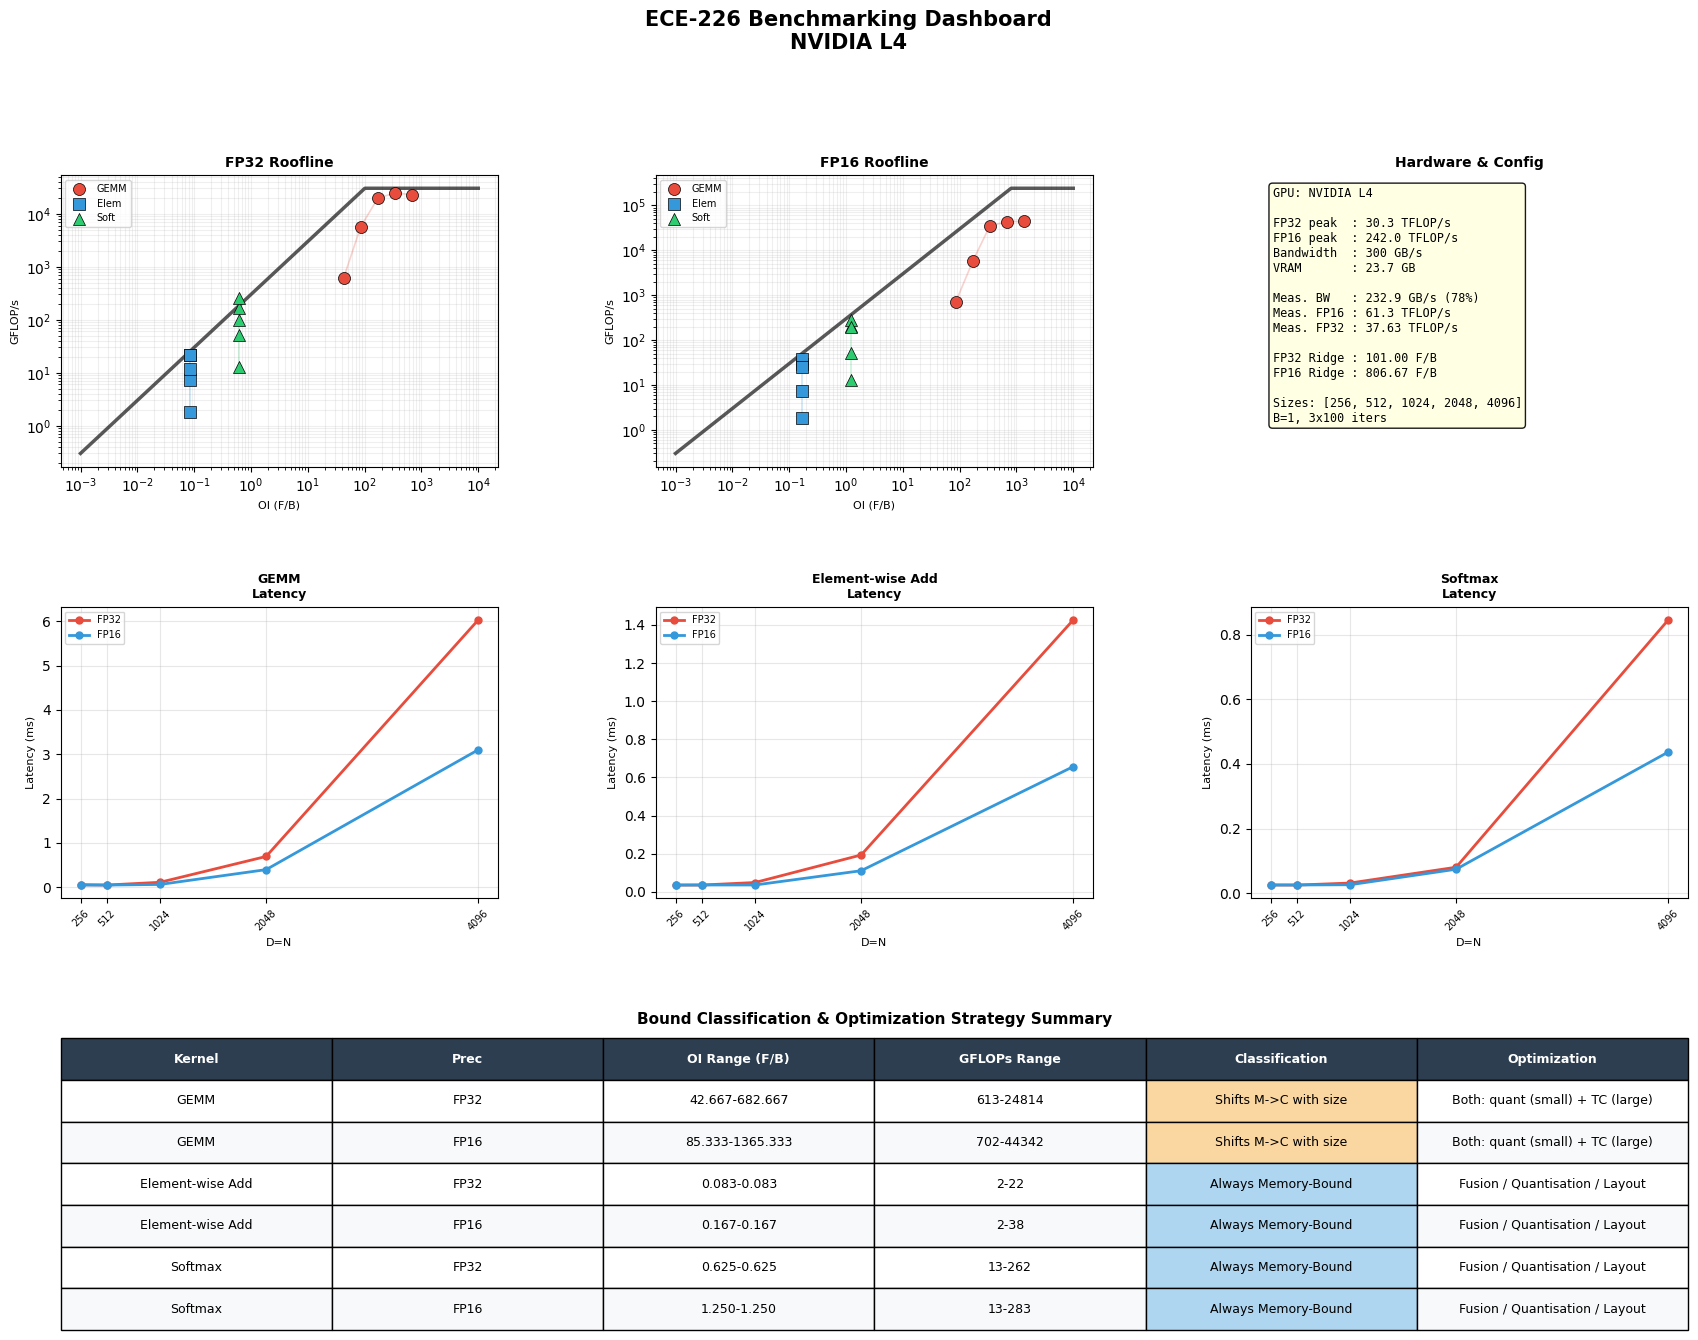

Dashboard saved as dashboard_summary.png


In [28]:
fig = plt.figure(figsize=(21, 15))
fig.suptitle(f'ECE-226 Benchmarking Dashboard\n{gpu_name}',
             fontsize=15, fontweight='bold', y=0.99)
gs = fig.add_gridspec(3, 3, hspace=0.48, wspace=0.36)

# Row 0: Roofline maps
for col, (prec, compute) in enumerate([('FP32',PEAK_FP32_TFLOPS),('FP16',PEAK_FP16_TFLOPS)]):
    ax = fig.add_subplot(gs[0, col])
    ax.set_xscale('log'); ax.set_yscale('log')
    oi_r = np.logspace(-3,4,1000); cg = compute*1000
    ax.plot(oi_r, np.minimum(cg, oi_r*PEAK_BW_GBs), 'k-', linewidth=2.5, alpha=0.65)
    for kname, ks in KERNEL_STYLES.items():
        kdf = df[(df['precision']==prec)&(df['kernel']==kname)].sort_values('hidden_dim')
        ax.scatter(kdf['operational_intensity'], kdf['achieved_gflops'],
                   color=ks['color'], marker=ks['marker'], s=75, zorder=10,
                   label=kname[:4], edgecolors='black', linewidths=0.5)
        ax.plot(kdf['operational_intensity'], kdf['achieved_gflops'],
                color=ks['color'], alpha=0.25, linewidth=1.2)
    ax.set_xlabel('OI (F/B)', fontsize=8); ax.set_ylabel('GFLOP/s', fontsize=8)
    ax.set_title(f'{prec} Roofline', fontsize=10, fontweight='bold')
    ax.legend(fontsize=7); ax.grid(True, which='both', alpha=0.2)

# Hardware box
ax_hw = fig.add_subplot(gs[0,2]); ax_hw.axis('off')
ax_hw.text(0.05, 0.96,
    f"GPU: {gpu_name}\n\n"
    f"FP32 peak  : {PEAK_FP32_TFLOPS:.1f} TFLOP/s\n"
    f"FP16 peak  : {PEAK_FP16_TFLOPS:.1f} TFLOP/s\n"
    f"Bandwidth  : {PEAK_BW_GBs:.0f} GB/s\n"
    f"VRAM       : {TOTAL_MEM_GB:.1f} GB\n\n"
    f"Meas. BW   : {meas_bw:.1f} GB/s ({100*meas_bw/PEAK_BW_GBs:.0f}%)\n"
    f"Meas. FP16 : {meas_fp16:.1f} TFLOP/s\n"
    f"Meas. FP32 : {meas_fp32:.2f} TFLOP/s\n\n"
    f"FP32 Ridge : {ridge_fp32:.2f} F/B\n"
    f"FP16 Ridge : {ridge_fp16:.2f} F/B\n\n"
    f"Sizes: {SIZES}\nB={BATCH_SIZE}, 3x100 iters",
    transform=ax_hw.transAxes, fontsize=8.5, va='top', fontfamily='monospace',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
ax_hw.set_title('Hardware & Config', fontsize=10, fontweight='bold')

# Row 1: Latency curves
for col, kname in enumerate(['GEMM','Element-wise Add','Softmax']):
    ax = fig.add_subplot(gs[1, col])
    kdf = df[df['kernel']==kname]
    for prec, color in kcolors.items():
        sub = kdf[kdf['precision']==prec].sort_values('hidden_dim')
        ax.plot(sub['hidden_dim'], sub['latency_ms'], color=color,
                marker='o', linewidth=2, markersize=5, label=prec)
    ax.set_xlabel('D=N', fontsize=8); ax.set_ylabel('Latency (ms)', fontsize=8)
    ax.set_title(f'{kname}\nLatency', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax.set_xticks(SIZES); ax.set_xticklabels(SIZES, rotation=45, fontsize=7)

# Row 2: Classification table
ax_cls = fig.add_subplot(gs[2,:]); ax_cls.axis('off')
cls_rows = []
for kname in ['GEMM','Element-wise Add','Softmax']:
    for prec in ['FP32','FP16']:
        sub = df[(df['kernel']==kname)&(df['precision']==prec)]
        oi_min = sub['operational_intensity'].min()
        oi_max = sub['operational_intensity'].max()
        gf_min = sub['achieved_gflops'].min()
        gf_max = sub['achieved_gflops'].max()
        ridge_v = ridge_fp32 if prec=='FP32' else ridge_fp16
        bound = ('Always Memory-Bound' if oi_max < ridge_v else
                 'Always Compute-Bound' if oi_min >= ridge_v else 'Shifts M->C with size')
        opt   = ('Tensor Cores / FP16 / Tiling' if bound=='Always Compute-Bound' else
                 'Fusion / Quantisation / Layout' if bound=='Always Memory-Bound' else
                 'Both: quant (small) + TC (large)')
        cls_rows.append([kname, prec, f"{oi_min:.3f}-{oi_max:.3f}",
                         f"{gf_min:.0f}-{gf_max:.0f}", bound, opt])
tbl = ax_cls.table(cellText=cls_rows,
                   colLabels=['Kernel','Prec','OI Range (F/B)','GFLOPs Range','Classification','Optimization'],
                   cellLoc='center', loc='center', bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2C3E50'); cell.set_text_props(color='white', fontweight='bold')
    elif row > 0 and col == 4:
        txt = cell.get_text().get_text()
        cell.set_facecolor('#AED6F1' if 'Memory' in txt else
                           '#ABEBC6' if 'Compute' in txt else '#FAD7A0')
    elif row % 2 == 0:
        cell.set_facecolor('#F8F9FA')
ax_cls.set_title('Bound Classification & Optimization Strategy Summary',
                 fontsize=11, fontweight='bold', pad=10)
plt.savefig('dashboard_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as dashboard_summary.png")


---
## Section 17 — Export Results


In [29]:
df['bound_fp32'] = df.apply(
    lambda r: classify(r['operational_intensity'],'FP32') if r['precision']=='FP32' else '', axis=1)
df['bound_fp16'] = df.apply(
    lambda r: classify(r['operational_intensity'],'FP16') if r['precision']=='FP16' else '', axis=1)
df['efficiency_pct'] = df.apply(
    lambda r: efficiency(r['achieved_gflops'], r['operational_intensity'], r['precision']), axis=1)
df.to_csv('benchmark_results_full.csv', index=False)

print("="*62)
print("FILES PRODUCED BY THIS NOTEBOOK")
print("="*62)
files = [
    ['benchmark_results_full.csv',     'All kernel measurements + classifications'],
    ['roofline_theoretical.png',        'Spec + empirical rooflines (FP32 & FP16)'],
    ['latency_vs_size.png',             'Latency curves per kernel'],
    ['oi_vs_size.png',                  'Operational Intensity vs size'],
    ['gflops_vs_size.png',              'Achieved GFLOPs vs size'],
    ['roofline_kernel_map.png',         '*** MAIN: All kernels on roofline ***'],
    ['fp32_vs_fp16_comparison.png',     'FP32 vs FP16 bar charts'],
    ['scaling_classification.png',      'Bound shift with problem size'],
    ['nsys_duration_distribution.png',  'nsys: kernel duration box/bar charts'],
    ['nsys_fp32_vs_fp16_duration.png',  'nsys: FP32 vs FP16 duration comparison'],
    ['nsys_timeline.png',               'nsys: GPU execution timeline'],
    ['nsys_cpu_gpu_overlap.png',        'nsys: CPU dispatch vs GPU compute overhead'],
    ['nsys_duration_sweep.png',         'nsys: duration vs size (all kernels)'],
    ['dashboard_summary.png',           'Full summary dashboard'],
]
print(tabulate(files, headers=['Filename','Description'], tablefmt='grid'))
print(f"\nTotal experiments: {len(df)}")
print(f"GPU     : {gpu_name}")
print(f"Kernels : GEMM, Element-wise Add, Softmax")
print(f"Sizes   : {SIZES}")
print(f"Prec    : FP32, FP16")
print(f"Profiling: nsys (Nsight Systems) + CUDA-event timing")


FILES PRODUCED BY THIS NOTEBOOK
+--------------------------------+--------------------------------------------+
| Filename                       | Description                                |
+================================+============================================+
| benchmark_results_full.csv     | All kernel measurements + classifications  |
+--------------------------------+--------------------------------------------+
| roofline_theoretical.png       | Spec + empirical rooflines (FP32 & FP16)   |
+--------------------------------+--------------------------------------------+
| latency_vs_size.png            | Latency curves per kernel                  |
+--------------------------------+--------------------------------------------+
| oi_vs_size.png                 | Operational Intensity vs size              |
+--------------------------------+--------------------------------------------+
| gflops_vs_size.png             | Achieved GFLOPs vs size                    |
+-------